# Graph Theory Analysis



# 1. Setup


## 1.1 Libraries and environment

In [ ]:
import importlib
import subprocess
import sys
from pathlib import Path

try:
  from neuroHarmonize import harmonizationLearn
  from neuroCombat import neuroCombat
except:
  !pip install neuroHarmonize
  !pip install neuroCombat
  from neuroHarmonize import harmonizationLearn
  from neuroCombat import neuroCombat

def ensure_package(import_name, pip_name=None):
    pip_name = pip_name or import_name
    try:
        return importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
        return importlib.import_module(import_name)

for import_name, pip_name in [
    ("numpy", None),
    ("pandas", None),
    ("matplotlib", None),
    ("seaborn", None),
    ("scipy", None),
    ("statsmodels", None),
    ("nilearn", None),
    ("bct", "bctpy"),
    ("neuroHarmonize", None),
]:
    ensure_package(import_name, pip_name)

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as exc:
    print(f"Google Drive was not mounted automatically: {exc}")
    print("If you are running outside Colab, make sure the paths below are valid.")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
from collections import Counter, defaultdict

from scipy.io import loadmat
from scipy.sparse.csgraph import shortest_path
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from IPython.display import display

import bct
from neuroHarmonize import harmonizationLearn
from nilearn import plotting
from nilearn.connectome import ConnectivityMeasure

from matplotlib.colors import TwoSlopeNorm
from matplotlib.cm import ScalarMappable

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1.2 Analysis configuration

In [ ]:
# -----------------------
# Paths
# -----------------------
DRIVE_ROOT = Path("/content/drive/MyDrive")
PROJECT_ROOT = DRIVE_ROOT / "M2/Impact Scholar Programme"
PREPROC_ROOT = PROJECT_ROOT / "Preprocessed_data"

# Fallback for the older graph-theory path layout.
if not PREPROC_ROOT.exists():
    PREPROC_ROOT = DRIVE_ROOT / "Preprocessed_data"
    PROJECT_ROOT = DRIVE_ROOT

OUTPUT_DIR = PROJECT_ROOT
PARTICIPANT_FILE = PREPROC_ROOT / "all_part.csv"

ROOT_PATHS = {
    "Ctrl": PREPROC_ROOT / "CONN_PREPROCESS_CTRL",
    "PDND": PREPROC_ROOT / "CONN_PREPROCESS_PD",
    "PDD": PREPROC_ROOT / "CONN_PREPROCESS_PD_DEP",
}

# -----------------------
# Subjects
# -----------------------
def list_subjects_from_preprocessed_folder(root_path):
    root_path = Path(root_path)
    if not root_path.exists():
        raise FileNotFoundError(
            f"Could not find preprocessing folder: {root_path}\n"
            "Check PREPROC_ROOT / ROOT_PATHS above before running the analysis."
        )

    subjects = sorted(
        int(item.name)
        for item in root_path.iterdir()
        if item.is_dir() and item.name.isdigit()
    )

    if len(subjects) == 0:
        raise ValueError(f"No numeric participant folders were found in: {root_path}")

    return subjects

SUBJECTS = {
    group_name: list_subjects_from_preprocessed_folder(root_path)
    for group_name, root_path in ROOT_PATHS.items()
}

# Compatibility aliases using the names from the harmonization notebook.
list_participants_ctrl = [str(s) for s in SUBJECTS["Ctrl"]]
list_participants_pd = [str(s) for s in SUBJECTS["PDND"]]
list_participants_pdd = [str(s) for s in SUBJECTS["PDD"]]

GROUP_ORDER = ["Ctrl", "PDND", "PDD"]

GROUP_PAIRS = [
    ("Ctrl", "PDND"),
    ("Ctrl", "PDD"),
    ("PDND", "PDD"),
]

COMPARISON_TAGS = {
    ("Ctrl", "PDND"): "Ctrl vs PDND",
    ("Ctrl", "PDD"): "Ctrl vs PDD",
    ("PDND", "PDD"): "PDND vs PDD",
}

GLOBAL_METRICS = [
    "strength",
    "efficiency",
    "clustering",
    "betweenness",
]
LOCAL_METRICS = [
    "nodal_strength",
    "nodal_betweenness",
    "nodal_clustering",
    "nodal_participation",
    "within_module_strength_zscore",
]

DENSITIES = np.arange(0.10, 0.31, 0.05)
P_THRESHOLD = 0.05
TOP_N = 15

# Extra metric settings
SMALL_WORLD_N_RANDOM = 20
SMALL_WORLD_RANDOM_SEED = 12345
HUB_CORE_FRACTION = 0.20

# Targeted network-level connectivity features.
TARGET_NETWORKS = ["DefaultMode", "Salience", "FrontoParietal"]

LITERATURE_PREFIXES = (
    "networks.DefaultMode.",
    "networks.Salience.",
    "networks.FrontoParietal.",
)

ROI15_RESULT_FILES = [
    f"{COMPARISON_TAGS[(g1, g2)]}_15_harmonized_{metric_name}.csv"
    for metric_name in LOCAL_METRICS
    for g1, g2 in GROUP_PAIRS
]

# -----------------------
# Harmonization
# -----------------------
# Set to True to run ComBat/neuroHarmonize before graph metric calculation.
# The graph analysis then uses harmonized connectivity matrices.
HARMONIZE_FC = True

# Columns used from all_part.csv
SITE_COLUMN = "Imaging Protocol"
AGE_COLUMN = "Age"
SEX_COLUMN = "Sex"

# Keep diagnosis/group effects during harmonization by adding group dummies
# as biological covariates.
INCLUDE_GROUP_DUMMIES_IN_HARMONIZATION = True

print("Using all available participants from preprocessing folders:")
for group_name in GROUP_ORDER:
    print(f"{group_name}: {len(SUBJECTS[group_name])} subjects")


Using all available participants from preprocessing folders:
Ctrl: 32 subjects
PDND: 32 subjects
PDD: 26 subjects


# 2. Data loading

## 2.1 Subject paths and QC table

In [ ]:
part_list = pd.read_csv(PARTICIPANT_FILE)

part_list["Subject ID"] = part_list["Subject ID"].astype(int)

def build_paths(subjects, root_path, group_name, participant_table):
    paths = {}
    rows = []

    for subject in subjects:
        subject_int = int(subject)
        mat_path = (
            root_path
            / str(subject_int)
            / str(subject_int)
            / "data"
            / "ROI_Subject001_Session001.mat"
        )

        match = participant_table[participant_table["Subject ID"] == subject_int]
        if not match.empty and "GDSCALE Total Score" in match.columns:
            gdsc = match["GDSCALE Total Score"].iloc[0]
            gdsc = 0 if pd.isna(gdsc) else int(gdsc)
        else:
            gdsc = np.nan

        paths[subject_int] = mat_path
        rows.append(
            {
                "group": group_name,
                "subject": subject_int,
                "exists": mat_path.exists(),
                "GDSC": gdsc,
                "path": str(mat_path),
            }
        )

    return paths, rows

GROUP_PATHS = {}
check_rows = []

for group_name in GROUP_ORDER:
    subjects = SUBJECTS[group_name]
    paths, rows = build_paths(subjects, ROOT_PATHS[group_name], group_name, part_list)
    GROUP_PATHS[group_name] = paths
    check_rows.extend(rows)

df_check = pd.DataFrame(check_rows)
display(df_check)

print("\nAvailability by group:")
print(df_check.groupby("group")["exists"].value_counts())

missing_roi = df_check[df_check["exists"] == False].copy()
if not missing_roi.empty:
    print("\nWARNING: These folders do not contain ROI_Subject001_Session001.mat and will be skipped:")
    display(missing_roi[["group", "subject", "path"]])

    SUBJECTS = {
        group_name: df_check[(df_check["group"] == group_name) & (df_check["exists"] == True)]["subject"].astype(int).tolist()
        for group_name in GROUP_ORDER
    }
    GROUP_PATHS = {
        group_name: {
            subject: GROUP_PATHS[group_name][subject]
            for subject in SUBJECTS[group_name]
        }
        for group_name in GROUP_ORDER
    }

print("\nFinal participants used:")
for group_name in GROUP_ORDER:
    print(f"{group_name}: {len(SUBJECTS[group_name])} subjects")


,group,subject,exists,GDSC,path
0,Ctrl,100890,True,0,/content/drive/MyDrive/Preprocessed_data/CONN_...
1,Ctrl,101195,True,0,/content/drive/MyDrive/Preprocessed_data/CONN_...
2,Ctrl,102447,True,0,/content/drive/MyDrive/Preprocessed_data/CONN_...
3,Ctrl,103161,True,1,/content/drive/MyDrive/Preprocessed_data/CONN_...
4,Ctrl,103183,True,1,/content/drive/MyDrive/Preprocessed_data/CONN_...
...,...,...,...,...,...
85,PDD,175837,True,6,/content/drive/MyDrive/Preprocessed_data/CONN_...
86,PDD,182427,True,12,/content/drive/MyDrive/Preprocessed_data/CONN_...
87,PDD,184432,True,10,/content/drive/MyDrive/Preprocessed_data/CONN_...
88,PDD,211482,True,5,/content/drive/MyDrive/Preprocessed_data/CONN_...



Availability by group:
group  exists
Ctrl   True      32
PDD    True      26
PDND   True      32
Name: count, dtype: int64

Final participants used:
Ctrl: 32 subjects
PDND: 32 subjects
PDD: 26 subjects


## 2.2 Harmonization metadata helpers

- `Ctrl` = controls from `CONN_PREPROCESS_CTRL`
- `PDND` = non-depressed PD from `CONN_PREPROCESS_PD`
- `PDD` = depressed PD from `CONN_PREPROCESS_PD_DEP`

The participant lists are now loaded dynamically from the folders.

In [ ]:
def clean_participant_table(participant_table):
    """
    Match the participant-table cleaning used in the harmonization notebook:
    keep rsfMRI_RL rows and one row per Subject ID.
    """
    df = participant_table.copy()

    if "Description" in df.columns:
        df = df[df["Description"].fillna("").astype(str).str.startswith("rsfMRI_RL")].copy()

    if "Subject ID" not in df.columns:
        raise ValueError("Participant table must contain a 'Subject ID' column.")

    df = df.drop_duplicates(subset="Subject ID")
    df["Subject ID"] = df["Subject ID"].astype(int)
    return df


def encode_sex_for_harmonization(sex_value):
    """
    Female=1, Male=0.
    Returns NaN if the value cannot be interpreted.
    """
    sex_text = str(sex_value).strip().upper()

    if sex_text.startswith("F"):
        return 1.0
    if sex_text.startswith("M"):
        return 0.0

    return np.nan


def simplify_site_label(site_value):
    """
    Keep only the manufacturer portion of strings such as:
    'Manufacturer=SIEMENS;TR=2500.0' -> 'Manufacturer=SIEMENS'
    """
    if pd.isna(site_value):
        return np.nan

    return str(site_value).split(";")[0].strip()


def build_harmonization_covariates(
    participant_table,
    subjects_by_group,
    group_order=GROUP_ORDER,
    site_column=SITE_COLUMN,
    age_column=AGE_COLUMN,
    sex_column=SEX_COLUMN,
    include_group_dummies=INCLUDE_GROUP_DUMMIES_IN_HARMONIZATION,
):
    """
    Build covariates in exactly the same subject order used when stacking
    the connectivity features for ComBat harmonization.
    """
    participant_clean = clean_participant_table(participant_table).set_index("Subject ID")
    rows = []
    missing_subjects = []

    for group_name in group_order:
        for subject in subjects_by_group[group_name]:
            subject_int = int(subject)

            if subject_int not in participant_clean.index:
                missing_subjects.append(subject_int)
                continue

            row = participant_clean.loc[subject_int]
            rows.append(
                {
                    "subject": subject_int,
                    "group": group_name,
                    "SITE": simplify_site_label(row[site_column]),
                    "AGE": float(row[age_column]),
                    "SEX": encode_sex_for_harmonization(row[sex_column]),
                }
            )

    if missing_subjects:
        raise ValueError(
            "These subjects were not found in the cleaned participant table: "
            f"{missing_subjects}"
        )

    metadata = pd.DataFrame(rows)

    required = ["SITE", "AGE", "SEX"]
    missing_covars = metadata[required].isna().any(axis=1)
    if missing_covars.any():
        display(metadata.loc[missing_covars, ["subject", "group"] + required])
        raise ValueError("Missing SITE, AGE, or SEX values were found. Fix these before harmonization.")

    covars = metadata[["SITE", "AGE", "SEX"]].copy()

    if include_group_dummies:
        group_dummies = pd.get_dummies(metadata["group"], prefix="GROUP", drop_first=True).astype(float)
        covars = pd.concat([covars, group_dummies], axis=1)

    return covars, metadata


# Quick check that covariates line up with your subject lists.
harmonization_covars_check, harmonization_metadata_check = build_harmonization_covariates(
    participant_table=part_list,
    subjects_by_group=SUBJECTS,
)

display(harmonization_metadata_check.head())
print("Covariate rows:", len(harmonization_covars_check))
print("Expected subjects:", sum(len(SUBJECTS[group]) for group in GROUP_ORDER))
print("\nSITE counts:")
print(harmonization_metadata_check["SITE"].value_counts())


,subject,group,SITE,AGE,SEX
0,100890,Ctrl,Manufacturer=Philips Medical Systems,78.2,0.0
1,101195,Ctrl,Manufacturer=SIEMENS,73.8,0.0
2,102447,Ctrl,Manufacturer=SIEMENS,60.8,0.0
3,103161,Ctrl,Manufacturer=SIEMENS,58.9,0.0
4,103183,Ctrl,Manufacturer=SIEMENS,57.7,0.0


Covariate rows: 90
Expected subjects: 90

SITE counts:
SITE
Manufacturer=SIEMENS                    66
Manufacturer=Philips Medical Systems    12
Manufacturer=GE MEDICAL SYSTEMS         12
Name: count, dtype: int64


# 3. Shared helper functions

## 3.1 ROI extraction and functional connectivity

In [ ]:
def normalize_roi_names(raw_names):
    return [name[0] if isinstance(name, np.ndarray) else name for name in raw_names[0]]

def load_roi_timeseries(path, selected_rois=None, prefixes=None, exclude_nuisance=True):
    mat = loadmat(path)
    roi_names = normalize_roi_names(mat["names"])
    roi_data = mat["data"]

    exclude = {"White Matter", "CSF", "Grey Matter"} if exclude_nuisance else set()
    available_index = {name: idx for idx, name in enumerate(roi_names) if name not in exclude}

    if selected_rois is not None:
        keep_names = [roi for roi in selected_rois if roi in available_index]
    elif prefixes is not None:
        keep_names = [roi for roi in roi_names if roi not in exclude and roi.startswith(prefixes)]
    else:
        keep_names = [roi for roi in roi_names if roi not in exclude]

    if len(keep_names) == 0:
        raise ValueError(f"No ROIs were selected for: {path}")

    keep_idx = [available_index[name] for name in keep_names]
    X = np.column_stack([np.asarray(roi_data[0, idx]).squeeze() for idx in keep_idx])

    return X, keep_names

def compute_fc(paths_dict, selected_rois=None, prefixes=None):
    X_list = []
    roi_labels = None

    for path in paths_dict.values():
        X, current_labels = load_roi_timeseries(path, selected_rois=selected_rois, prefixes=prefixes)

        if roi_labels is None:
            roi_labels = current_labels
        else:
            assert current_labels == roi_labels, "ROI labels changed across subjects."

        X_list.append(X)

    conn = ConnectivityMeasure(kind="correlation", standardize="zscore_sample")
    FC_r = conn.fit_transform(X_list)

    # Clip before Fisher z to avoid inf values
    FC_z = np.arctanh(np.clip(FC_r, -0.999999, 0.999999))
    FC_mean_z = FC_z.mean(axis=0)
    FC_mean_r = np.tanh(FC_mean_z)

    return FC_r, FC_mean_r, roi_labels

def fc_to_graph(FC_all):
    W_all = []
    for FC in FC_all:
        FC = FC.copy()
        np.fill_diagonal(FC, 0)
        W_all.append(np.abs(FC))
    return np.asarray(W_all)

## 3.2 Functional-connectivity harmonization

This is the actual harmonization step added to your graph-theory workflow. It harmonizes the **upper-triangle Fisher-z connectivity features** across scanner/site, while preserving age, sex, and group effects. The harmonized connectivity matrices are then passed into the existing graph-theory metrics.


In [ ]:
def flatten_upper_triangle(mats):
    """
    Convert symmetric matrices with shape (n_subjects, n_roi, n_roi)
    into feature rows using the upper triangle only.
    """
    mats = np.asarray(mats, dtype=float)
    if mats.ndim != 3 or mats.shape[1] != mats.shape[2]:
        raise ValueError("Expected mats with shape (n_subjects, n_roi, n_roi).")

    n_roi = mats.shape[1]
    rows, cols = np.triu_indices(n_roi, k=1)
    return mats[:, rows, cols], rows, cols


def unflatten_upper_triangle(features, n_roi, rows, cols, diagonal_value=1.0):
    """
    Rebuild symmetric matrices from upper-triangle feature rows.
    """
    features = np.asarray(features, dtype=float)
    mats = np.zeros((features.shape[0], n_roi, n_roi), dtype=float)

    mats[:, rows, cols] = features
    mats[:, cols, rows] = features

    for i in range(features.shape[0]):
        np.fill_diagonal(mats[i], diagonal_value)

    return mats


def plot_harmonization_distributions(X_before, X_after, metadata, value_sample=None):
    """
    Lightweight diagnostic plots for before/after harmonization.
    """
    def to_long_dataframe(X, stage):
        X_plot = np.asarray(X)
        if value_sample is not None and X_plot.shape[1] > value_sample:
            rng = np.random.default_rng(0)
            chosen = np.sort(rng.choice(X_plot.shape[1], size=value_sample, replace=False))
            X_plot = X_plot[:, chosen]

        df = pd.DataFrame(X_plot)
        df["subject"] = metadata["subject"].values
        df["group"] = metadata["group"].values
        df["SITE"] = metadata["SITE"].values
        df["stage"] = stage

        return df.melt(
            id_vars=["subject", "group", "SITE", "stage"],
            var_name="edge",
            value_name="value",
        )

    df_plot = pd.concat(
        [
            to_long_dataframe(X_before, "Before ComBat"),
            to_long_dataframe(X_after, "After ComBat"),
        ],
        ignore_index=True,
    )

    sns.displot(
        data=df_plot,
        x="value",
        hue="SITE",
        col="stage",
        kind="kde",
        common_norm=False,
        fill=True,
        height=4,
        aspect=1.2,
    )
    plt.suptitle("Connectivity-feature distributions by scanner/site", y=1.05)
    plt.show()

    sns.displot(
        data=df_plot,
        x="value",
        hue="group",
        col="stage",
        kind="kde",
        common_norm=False,
        fill=True,
        height=4,
        aspect=1.2,
    )
    plt.suptitle("Connectivity-feature distributions by group", y=1.05)
    plt.show()


def harmonize_fc_by_group(
    fc_by_group,
    participant_table,
    subjects_by_group,
    group_order=GROUP_ORDER,
    plot_diagnostics=False,
):
    """
    Harmonize FC matrices before graph theory.

    Steps:
    1. Convert each subject's FC matrix from r to Fisher z.
    2. Flatten the upper triangle into ComBat features.
    3. Harmonize using SITE as batch and AGE, SEX, and group dummies as covariates.
    4. Rebuild symmetric matrices and convert z back to r.
    """
    missing_groups = [group for group in group_order if group not in fc_by_group]
    if missing_groups:
        raise ValueError(f"Missing groups in fc_by_group: {missing_groups}")

    n_roi = next(iter(fc_by_group.values())).shape[1]

    X_parts = []
    group_lengths = {}

    rows = cols = None
    for group_name in group_order:
        FC_r = np.asarray(fc_by_group[group_name], dtype=float)
        if FC_r.shape[1:] != (n_roi, n_roi):
            raise ValueError(f"ROI dimension mismatch for group {group_name}: {FC_r.shape}")

        FC_z = np.arctanh(np.clip(FC_r, -0.999999, 0.999999))
        X_group, rows, cols = flatten_upper_triangle(FC_z)

        X_parts.append(X_group)
        group_lengths[group_name] = X_group.shape[0]

    X = np.vstack(X_parts)

    covars, metadata = build_harmonization_covariates(
        participant_table=participant_table,
        subjects_by_group=subjects_by_group,
        group_order=group_order,
    )

    if len(covars) != X.shape[0]:
        raise ValueError(
            f"Covariate rows ({len(covars)}) do not match feature rows ({X.shape[0]}). "
            "Check GROUP_ORDER and SUBJECTS."
        )

    print("ComBat input feature matrix:", X.shape)
    print("ComBat covariates:", list(covars.columns))
    print("Group order:", group_order)

    model, X_harmonized = harmonizationLearn(data=X, covars=covars)

    print("ComBat output feature matrix:", X_harmonized.shape)
    print("NaNs after harmonization:", np.isnan(X_harmonized).sum())
    print("Infs after harmonization:", np.isinf(X_harmonized).sum())

    if plot_diagnostics:
        plot_harmonization_distributions(X, X_harmonized, metadata, value_sample=500)

    fc_harmonized_by_group = {}
    split_indices = np.cumsum([group_lengths[group] for group in group_order])[:-1]
    X_split = np.split(X_harmonized, split_indices, axis=0)

    for group_name, X_group_harmonized in zip(group_order, X_split):
        FC_z_harmonized = unflatten_upper_triangle(
            X_group_harmonized,
            n_roi=n_roi,
            rows=rows,
            cols=cols,
            diagonal_value=0.0,
        )
        FC_r_harmonized = np.tanh(FC_z_harmonized)

        for i in range(FC_r_harmonized.shape[0]):
            np.fill_diagonal(FC_r_harmonized[i], 1.0)

        fc_harmonized_by_group[group_name] = FC_r_harmonized

    harmonization_info = {
        "model": model,
        "metadata": metadata,
        "covars": covars,
        "X_before_fisher_z": X,
        "X_after_fisher_z": X_harmonized,
        "group_lengths": group_lengths,
        "rows": rows,
        "cols": cols,
    }

    return fc_harmonized_by_group, harmonization_info


## 3.2 Graph metrics and statistics

In [ ]:
def threshold_proportional(W, density=0.2):
    W = np.array(W, dtype=float, copy=True)
    np.fill_diagonal(W, 0)

    n = W.shape[0]
    iu = np.triu_indices(n, 1)
    edge_weights = W[iu]

    n_keep = int(np.floor(density * len(edge_weights)))
    if n_keep < 1:
        return np.zeros_like(W)

    keep_idx = np.argsort(edge_weights)[-n_keep:]

    W_thr = np.zeros_like(W)
    W_thr[iu[0][keep_idx], iu[1][keep_idx]] = edge_weights[keep_idx]
    W_thr = W_thr + W_thr.T
    np.fill_diagonal(W_thr, 0)

    return W_thr


def weights_to_lengths(W):
    L = np.full(W.shape, np.inf, dtype=float)
    mask = W > 0
    L[mask] = 1.0 / W[mask]
    np.fill_diagonal(L, 0)
    return L


def _finite_or(value, default=np.nan):
    """Return a finite scalar, otherwise a default value."""
    try:
        value = float(value)
    except Exception:
        return default
    return value if np.isfinite(value) else default


def _auc_from_curve(curve, densities=DENSITIES, fill_value=0.0):
    """AUC helper that prevents one failed density from breaking the whole subject."""
    curve = np.asarray(curve, dtype=float)
    curve = np.nan_to_num(curve, nan=fill_value, posinf=fill_value, neginf=fill_value)
    return float(np.trapezoid(curve, densities))


def shortest_path_lengths_from_weights(W):
    """Weighted shortest-path matrix using inverse connectivity strength as distance."""
    L = weights_to_lengths(W)
    D = shortest_path(csgraph=L, directed=False, unweighted=False)
    np.fill_diagonal(D, 0)
    return D


def weighted_modularity_communities(W):
    """Return weighted modularity communities and Q; safe fallback for sparse/empty graphs."""
    W = np.asarray(W, dtype=float)
    n = W.shape[0]

    if np.allclose(W, 0):
        return np.arange(n), 0.0

    try:
        ci, q = bct.modularity_und(W)
        ci = np.asarray(ci).ravel()

        if ci.size != n:
            ci = np.arange(n)
            q = 0.0

        return ci, _finite_or(q, default=0.0)
    except Exception:
        return np.arange(n), 0.0

def weighted_participation_coef(W, communities):
    """
    Weighted participation coefficient based on a community assignment,
    using bctpy while preserving the previous manual function's behavior.
    """
    W = np.asarray(W, dtype=float)
    communities = np.asarray(communities).ravel()

    if W.ndim != 2 or W.shape[0] != W.shape[1]:
        raise ValueError("W must be a square 2D adjacency matrix.")

    if communities.shape[0] != W.shape[0]:
        raise ValueError("communities must have length equal to W.shape[0].")

    strengths = W.sum(axis=1)

    with np.errstate(divide="ignore", invalid="ignore"):
        participation = bct.participation_coef(W, communities, degree="out")

    # Preserve your manual implementation's handling of zero/negative strength
    participation = np.asarray(participation, dtype=float)
    participation[strengths <= 0] = 0.0

    return np.nan_to_num(participation, nan=0.0, posinf=0.0, neginf=0.0)


def within_module_strength_zscore(W, communities, *, zero_diagonal=False):
    """
    Weighted within-module z-score using bctpy.
    """
    W = np.asarray(W, dtype=float)
    communities = np.asarray(communities).ravel()

    if W.ndim != 2 or W.shape[0] != W.shape[1]:
        raise ValueError("W must be a square 2D adjacency matrix.")

    if communities.shape[0] != W.shape[0]:
        raise ValueError("communities must have length equal to W.shape[0].")

    W_bct = W.copy()

    # Keep False to reproduce your manual implementation exactly.
    # Use True if W may contain self-connections and you want paper-style graph behavior.
    if zero_diagonal:
        np.fill_diagonal(W_bct, 0.0)

    with np.errstate(divide="ignore", invalid="ignore"):
        z = bct.module_degree_zscore(W_bct, communities, flag=0)

    return np.nan_to_num(z, nan=0.0, posinf=0.0, neginf=0.0)


def safe_mannwhitney_2group(x, y):
    """Mann-Whitney wrapper that handles NaNs and identical values safely."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]

    if len(x) < 2 or len(y) < 2:
        return np.nan, 1.0, np.nan, np.nan, np.nan, np.nan, np.nan

    mean_x = float(np.mean(x))
    mean_y = float(np.mean(y))
    median_x = float(np.median(x))
    median_y = float(np.median(y))
    delta = mean_y - mean_x

    if np.allclose(np.concatenate([x, y]), np.concatenate([x, y])[0]):
        return 0.0, 1.0, mean_x, mean_y, median_x, median_y, delta

    try:
        u_stat, p = mannwhitneyu(x, y, alternative="two-sided")
        return _finite_or(u_stat, default=np.nan), _finite_or(p, default=1.0), mean_x, mean_y, median_x, median_y, delta
    except Exception:
        return np.nan, 1.0, mean_x, mean_y, median_x, median_y, delta


def compute_graph_metrics(W_all, group_name, subject_ids, densities=DENSITIES):
    rows = []

    for i, W in enumerate(W_all):
        strength_curve = []
        clustering_curve = []
        efficiency_curve = []
        betweenness_curve = []

        for density_index, density in enumerate(densities):
            W_thr = threshold_proportional(W, density=density)
            L_thr = weights_to_lengths(W_thr)
            rng = np.random.default_rng(SMALL_WORLD_RANDOM_SEED + 1000 * i + density_index)

            strength_curve.append(np.sum(W_thr, axis=1).mean())
            clustering_curve.append(np.nanmean(bct.clustering_coef_wu(W_thr)))
            efficiency_curve.append(bct.efficiency_wei(W_thr))
            betweenness_curve.append(np.nanmean(bct.betweenness_wei(L_thr)))

        rows.append(
            {
                "subject": subject_ids[i],
                "group": group_name,
                "strength": _auc_from_curve(strength_curve, densities),
                "clustering": _auc_from_curve(clustering_curve, densities),
                "efficiency": _auc_from_curve(efficiency_curve, densities),
                "betweenness": _auc_from_curve(betweenness_curve, densities),
            }
        )

    return pd.DataFrame(rows)


def run_global_tests(df_graph, metrics=GLOBAL_METRICS, group_pairs=GROUP_PAIRS):
    stats_results = {}

    for g1, g2 in group_pairs:
        rows = []

        for metric in metrics:
            x = df_graph[df_graph["group"] == g1][metric]
            y = df_graph[df_graph["group"] == g2][metric]
            U, p, mean_x, mean_y, median_x, median_y, delta = safe_mannwhitney_2group(x, y)
            rows.append({"metric": metric, "U": U, "p_raw": p})

        df_stats = pd.DataFrame(rows)
        reject, p_fdr, _, _ = multipletests(df_stats["p_raw"], method="fdr_bh")
        df_stats["p_fdr"] = p_fdr
        df_stats["significant_fdr"] = reject
        df_stats = df_stats.sort_values(["p_raw", "p_fdr"]).reset_index(drop=True)

        stats_results[f"{g1}_vs_{g2}"] = df_stats

    return stats_results


def display_global_stats(stats_results, title_prefix="Global metrics"):
    for comparison, df_stats in stats_results.items():
        print(f"\n{title_prefix} - {comparison}")
        display(df_stats)


def compute_local_metrics_auc(W_all, densities=DENSITIES):
    out = {
        "nodal_strength": [],
        "nodal_betweenness": [],
        "nodal_clustering": [],
        "nodal_participation": [],
        "within_module_strength_zscore": [],
    }

    for W in W_all:
        curves = {key: [] for key in out}

        for density in densities:
            W_thr = threshold_proportional(W, density=density)
            L_thr = weights_to_lengths(W_thr)
            communities, _ = weighted_modularity_communities(W_thr)

            curves["nodal_strength"].append(np.sum(W_thr, axis=1))
            curves["nodal_betweenness"].append(bct.betweenness_wei(L_thr))
            curves["nodal_clustering"].append(bct.clustering_coef_wu(W_thr))
            curves["nodal_participation"].append(weighted_participation_coef(W_thr, communities))
            curves["within_module_strength_zscore"].append(within_module_strength_zscore(W_thr, communities))

        for key in curves:
            curves[key] = np.vstack(curves[key])
            curves[key] = np.nan_to_num(curves[key], nan=0.0, posinf=0.0, neginf=0.0)
            out[key].append(np.trapezoid(curves[key], densities, axis=0))

    return {key: np.vstack(value) for key, value in out.items()}


def extract_network(roi_name):
    parts = str(roi_name).split(".")
    return parts[1] if len(parts) > 1 else "Unknown"


def nodewise_group_comparison(group_1, group_2, roi_names, metric_name, group_1_name, group_2_name):
    rows = []
    pvals = []
    comparison = f"{group_1_name}_vs_{group_2_name}"

    for i, roi in enumerate(roi_names):
        x = group_1[:, i]
        y = group_2[:, i]

        u_stat, p, mean_x, mean_y, median_x, median_y, delta = safe_mannwhitney_2group(x, y)

        rows.append(
            {
                "metric": metric_name,
                "ROI_name": roi,
                "network": extract_network(roi),
                "group_1": group_1_name,
                "group_2": group_2_name,
                "comparison": comparison,
                "mean_group_1": mean_x,
                "mean_group_2": mean_y,
                "median_group_1": median_x,
                "median_group_2": median_y,
                "delta_mean_group2_minus_group1": delta,
                "u_stat": u_stat,
                "p_uncorrected": p,
            }
        )
        pvals.append(p)

    df = pd.DataFrame(rows)

    reject, p_fdr, _, _ = multipletests(pvals, method="fdr_bh")
    df["p_fdr"] = p_fdr
    df["significant_fdr"] = reject
    df["significant_uncorrected"] = df["p_uncorrected"] < P_THRESHOLD
    df["abs_delta"] = df["delta_mean_group2_minus_group1"].abs()

    df = df.sort_values(
        ["significant_uncorrected", "p_uncorrected", "abs_delta"],
        ascending=[False, True, False],
    ).reset_index(drop=True)

    return df


def combine_local_results(local_results):
    if len(local_results) == 0:
        return pd.DataFrame()

    return (
        pd.concat(local_results.values(), ignore_index=True)
        .sort_values(["p_uncorrected", "abs_delta"], ascending=[True, False])
        .reset_index(drop=True)
    )


def load_saved_results(file_names):
    dfs = [pd.read_csv(OUTPUT_DIR / file_name) for file_name in file_names]
    df_all = pd.concat(dfs, ignore_index=True)

    if "comparison" not in df_all.columns:
        df_all["comparison"] = df_all["group_1"] + "_vs_" + df_all["group_2"]

    if "abs_delta" not in df_all.columns:
        df_all["abs_delta"] = df_all["delta_mean_group2_minus_group1"].abs()

    if "significant_uncorrected" not in df_all.columns:
        df_all["significant_uncorrected"] = df_all["p_uncorrected"] < P_THRESHOLD

    return df_all.sort_values(["p_uncorrected", "abs_delta"], ascending=[True, False]).reset_index(drop=True)


def select_top_rois(df_all, top_n=TOP_N, ranking="significance_then_effect"):
    df_rank = df_all.copy()

    if ranking == "significance_then_effect":
        ranked = (
            df_rank.sort_values(
                ["significant_uncorrected", "p_uncorrected", "abs_delta"],
                ascending=[False, True, False],
            )
            .drop_duplicates(subset="ROI_name")
            .reset_index(drop=True)
        )
    elif ranking == "combined_rank":
        df_rank["rank_p"] = df_rank["p_uncorrected"].rank(method="min")
        df_rank["rank_effect"] = df_rank["abs_delta"].rank(ascending=False, method="min")
        df_rank["combined_rank"] = df_rank["rank_p"] + df_rank["rank_effect"]

        ranked = (
            df_rank.sort_values(["combined_rank", "p_uncorrected", "abs_delta"], ascending=[True, True, False])
            .drop_duplicates(subset="ROI_name")
            .reset_index(drop=True)
        )
    else:
        raise ValueError("ranking must be 'significance_then_effect' or 'combined_rank'")

    return ranked.head(top_n)["ROI_name"].tolist(), ranked


In [ ]:
def fisher_z_safe(r_values):
    """Fisher-z transform with clipping to avoid infinities."""
    r_values = np.asarray(r_values, dtype=float)
    r_values = np.clip(r_values, -0.999999, 0.999999)
    return np.arctanh(r_values)


def compute_target_network_connectivity(fc_matrices, roi_labels, subject_ids, group_name, target_networks=TARGET_NETWORKS):
    """Compute within-network and between-network mean FC for the target networks.

    These features are complementary to graph topology. They are especially useful for
    PDND vs PDD because the literature often points to Default Mode, Salience, and
    Fronto-Parietal/Cognitive Control network alterations.
    """
    rows = []
    roi_networks = np.asarray([extract_network(label) for label in roi_labels])

    for subject_index, FC in enumerate(fc_matrices):
        feature_values = {
            "subject": subject_ids[subject_index],
            "group": group_name,
        }

        for network in target_networks:
            idx = np.where(roi_networks == network)[0]
            if idx.size >= 2:
                sub = FC[np.ix_(idx, idx)]
                vals = sub[np.triu_indices(idx.size, k=1)]
                feature_values[f"within_{network}"] = float(np.nanmean(fisher_z_safe(vals)))
            else:
                feature_values[f"within_{network}"] = np.nan

        for i, network_1 in enumerate(target_networks):
            for network_2 in target_networks[i + 1:]:
                idx_1 = np.where(roi_networks == network_1)[0]
                idx_2 = np.where(roi_networks == network_2)[0]
                if idx_1.size > 0 and idx_2.size > 0:
                    vals = FC[np.ix_(idx_1, idx_2)].ravel()
                    feature_values[f"between_{network_1}_{network_2}"] = float(np.nanmean(fisher_z_safe(vals)))
                else:
                    feature_values[f"between_{network_1}_{network_2}"] = np.nan

        rows.append(feature_values)

    return pd.DataFrame(rows)


def run_target_network_connectivity_tests(df_network, group_pairs=GROUP_PAIRS):
    """Run group comparisons for targeted within/between-network FC features."""
    id_cols = {"subject", "group", "scope"}
    feature_cols = [c for c in df_network.columns if c not in id_cols]
    all_results = []

    for g1, g2 in group_pairs:
        rows = []
        for feature in feature_cols:
            x = df_network[df_network["group"] == g1][feature]
            y = df_network[df_network["group"] == g2][feature]
            u_stat, p, mean_x, mean_y, median_x, median_y, delta = safe_mannwhitney_2group(x, y)
            rows.append(
                {
                    "feature": feature,
                    "group_1": g1,
                    "group_2": g2,
                    "comparison": f"{g1}_vs_{g2}",
                    "mean_group_1": mean_x,
                    "mean_group_2": mean_y,
                    "median_group_1": median_x,
                    "median_group_2": median_y,
                    "delta_mean_group2_minus_group1": delta,
                    "u_stat": u_stat,
                    "p_uncorrected": p,
                }
            )

        df_stats = pd.DataFrame(rows)
        reject, p_fdr, _, _ = multipletests(df_stats["p_uncorrected"], method="fdr_bh")
        df_stats["p_fdr"] = p_fdr
        df_stats["significant_fdr"] = reject
        df_stats["significant_uncorrected"] = df_stats["p_uncorrected"] < P_THRESHOLD
        df_stats["abs_delta"] = df_stats["delta_mean_group2_minus_group1"].abs()
        all_results.append(df_stats)

    return (
        pd.concat(all_results, ignore_index=True)
        .sort_values(["comparison", "p_uncorrected", "abs_delta"], ascending=[True, True, False])
        .reset_index(drop=True)
    )

def edgewise_group_comparison(fc_by_group, roi_labels, group_1, group_2):
    import numpy as np
    import pandas as pd
    from statsmodels.stats.multitest import multipletests

    FC1 = np.asarray(fc_by_group[group_1], dtype=float)
    FC2 = np.asarray(fc_by_group[group_2], dtype=float)

    # Fisher z
    Z1 = np.arctanh(np.clip(FC1, -0.999999, 0.999999))
    Z2 = np.arctanh(np.clip(FC2, -0.999999, 0.999999))

    n = len(roi_labels)
    rows, cols = np.triu_indices(n, k=1)

    results, pvals = [], []

    for i, j in zip(rows, cols):
        x, y = Z1[:, i, j], Z2[:, i, j]

        from scipy.stats import mannwhitneyu
        stat, p = mannwhitneyu(x, y, alternative="two-sided")

        delta = np.mean(y) - np.mean(x)

        results.append({
            "ROI_1": roi_labels[i],
            "ROI_2": roi_labels[j],
            "comparison": f"{group_1}_vs_{group_2}",
            "delta_z": delta,
            "p_uncorrected": p
        })
        pvals.append(p)

    df = pd.DataFrame(results)

    df["p_fdr"] = multipletests(pvals, method="fdr_bh")[1]
    df["sig_unc"] = df["p_uncorrected"] < 0.05
    df["sig_fdr"] = df["p_fdr"] < 0.05

    return df.sort_values("p_uncorrected")

In [ ]:
print("Global metrics included:")
for metric_name in GLOBAL_METRICS:
    print("-", metric_name)

print("\nNodal/local metrics included:")
for metric_name in LOCAL_METRICS:
    print("-", metric_name)


Global metrics included:
- strength
- efficiency
- clustering
- betweenness

Nodal/local metrics included:
- nodal_strength
- nodal_betweenness
- nodal_clustering
- nodal_participation
- within_module_strength_zscore


## 3.3 Plotting helpers
> Regular analysis sections show tables and bar plots only.

In [ ]:
from IPython.display import display
import re

def show_local_results(df, title, n=10, p_threshold=P_THRESHOLD):
    cols = [
        "ROI_name",
        "metric",
        "comparison",
        "network",
        "delta_mean_group2_minus_group1",
        "p_uncorrected",
        "p_fdr",
        "significant_uncorrected",
        "significant_fdr",
    ]

    print(f"\n{title}")

    df_sig = (
        df[df["p_uncorrected"] < p_threshold]
        .sort_values(["p_uncorrected", "abs_delta"], ascending=[True, False])
        .copy()
    )

    if len(df_sig) > 0:
        print(f"ROIs with p < {p_threshold}: {len(df_sig)}")
        display(df_sig[cols].head(n))
    else:
        print(f"No ROIs with p < {p_threshold}.")


def _select_plot_rows(df, n=15, p_threshold=P_THRESHOLD):
    df_plot = df[df["p_uncorrected"] < p_threshold].copy()

    if df_plot.empty:
        df_plot = df.copy()

    df_plot = (
        df_plot.sort_values(["p_uncorrected", "abs_delta"], ascending=[True, False])
        .head(n)
        .sort_values("delta_mean_group2_minus_group1")
    )
    return df_plot


def plot_top_local_changes(df, title, n=15, p_threshold=P_THRESHOLD):
    df_plot = _select_plot_rows(df, n=n, p_threshold=p_threshold).reset_index(drop=True)

    formatted_title = format_brain_plot_title(title)

    fig, ax = plt.subplots(figsize=(10.5, max(4, 0.4 * len(df_plot))))
    sns.barplot(
        data=df_plot,
        x="delta_mean_group2_minus_group1",
        y="ROI_name",
        orient="h",
        ax=ax,
    )

    ax.axvline(0, linestyle="--", color="black")
    ax.set_xlabel("Mean difference (group 2 - group 1)")
    ax.set_ylabel("ROI")
    ax.set_title(formatted_title)

    # --- make room for p-value labels ---
    max_abs = np.nanmax(np.abs(df_plot["delta_mean_group2_minus_group1"].values))
    if not np.isfinite(max_abs) or max_abs == 0:
        max_abs = 1e-12

    x_margin = max_abs * 0.35
    ax.set_xlim(-max_abs - x_margin, max_abs + x_margin)

    # --- add p-value next to each bar ---
    pad = max_abs * 0.03
    if pad == 0:
        pad = 0.001

    for patch, (_, row) in zip(ax.patches, df_plot.iterrows()):
        width = patch.get_width()
        y_center = patch.get_y() + patch.get_height() / 2
        p_text = f"p={row['p_uncorrected']:.3g}"

        if width >= 0:
            x_text = width + pad
            ha = "left"
        else:
            x_text = width - pad
            ha = "right"

        ax.text(
            x_text,
            y_center,
            p_text,
            va="center",
            ha=ha,
            fontsize=10,
            color="black",
        )

    plt.tight_layout()
    plt.show()

    return df_plot

def clean_roi_label(roi):
    roi = str(roi)

    # Remove leading "networks."
    roi = re.sub(r"^networks\.", "", roi)

    # Remove trailing coordinates like:
    # (47,-67,29), (-46,-58,49), (1,55,-3), etc.
    roi = re.sub(r"\s*\([^)]+\)\s*$", "", roi)

    return roi

def plot_combined_metric_rois(
    selected_rows_by_metric,
    title,
    group1_name=None,
    group2_name=None,
    p_threshold=P_THRESHOLD,
    value_col="delta_mean_group2_minus_group1",
    roi_col="ROI_name",
    p_col="p_uncorrected",
):
    """
    Plot only significant ROIs from multiple metrics in one combined bar plot.

    group1_name and group2_name control the x-axis label:
    Mean difference (group2_name - group1_name)
    """

    combined = []

    for metric, metric_df in selected_rows_by_metric.items():
        if metric_df is None or metric_df.empty:
            continue

        temp = metric_df.copy()

        temp = temp[
            np.isfinite(temp[p_col]) &
            (temp[p_col] < p_threshold)
        ].copy()

        if temp.empty:
            continue

        temp["metric"] = metric
        temp["ROI_clean_label"] = temp[roi_col].apply(clean_roi_label)

        combined.append(temp)

    if not combined:
        print(f"No significant ROIs found for: {title}")
        return None

    df_combined = pd.concat(combined, ignore_index=True)

    df_combined = df_combined.sort_values(
        value_col,
        ascending=True
    ).reset_index(drop=True)

    fig, ax = plt.subplots(
        figsize=(11, max(4, 0.55 * len(df_combined)))
    )

    sns.barplot(
        data=df_combined,
        x=value_col,
        y="ROI_clean_label",
        hue="metric",
        dodge=False,
        orient="h",
        ax=ax,
    )

    ax.axvline(0, linestyle="--", color="black")

    if group1_name is not None and group2_name is not None:
        ax.set_xlabel(f"Mean difference ({group2_name} - {group1_name})")
    else:
        ax.set_xlabel("Mean difference (group 2 - group 1)")

    ax.set_ylabel("Significant ROI")
    ax.set_title(format_brain_plot_title(title))

    max_abs = np.nanmax(np.abs(df_combined[value_col].values))
    if not np.isfinite(max_abs) or max_abs == 0:
        max_abs = 1e-12

    x_margin = max_abs * 0.35
    ax.set_xlim(-max_abs - x_margin, max_abs + x_margin)

    pad = max_abs * 0.03
    if pad == 0:
        pad = 0.001

    for patch, (_, row) in zip(ax.patches, df_combined.iterrows()):
        width = patch.get_width()
        y_center = patch.get_y() + patch.get_height() / 2
        p_text = f"p={row[p_col]:.3g}"

        if width >= 0:
            x_text = width + pad
            ha = "left"
        else:
            x_text = width - pad
            ha = "right"

        ax.text(
            x_text,
            y_center,
            p_text,
            va="center",
            ha=ha,
            fontsize=10,
            color="black",
        )

    ax.legend(title="Metric", loc="best")
    plt.tight_layout()
    plt.show()

    return df_combined

# =========================================================
# Real-coordinate brain plotting helpers
# =========================================================

COMPARISON_LABEL_MAP = {
    "Ctrl_vs_PDND": "Ctrl vs PDND",
    "Ctrl_vs_PDD": "Ctrl vs PDD",
    "PDND_vs_PDD": "PDND vs PDD",
    "ctrl_vs_pdnd": "Ctrl vs PDND",
    "ctrl_vs_pdd": "Ctrl vs PDD",
    "pdnd_vs_pdd": "PDND vs PDD",
}

METRIC_LABEL_MAP = {
    "nodal_strength": "Nodal strength",
    "nodal_clustering": "Nodal clustering",
    "nodal_betweenness": "Nodal betweenness",
}


def extract_real_coords(roi_name):
    """
    Extract real coordinates from ROI labels such as:
    'networks.FrontoParietal.LPFC (L) (-43,33,28)'
    """
    match = re.search(r"\((-?\d+),\s*(-?\d+),\s*(-?\d+)\)", str(roi_name))
    if match:
        return tuple(map(int, match.groups()))
    return None


def prepare_real_coord_plot_df(df):
    df_plot = df.copy()

    if "ROI_name" in df_plot.columns:
        df_plot["ROI"] = df_plot["ROI_name"]
    elif "ROI" not in df_plot.columns:
        raise ValueError("DataFrame must contain either 'ROI_name' or 'ROI'.")

    if "delta_mean_group2_minus_group1" in df_plot.columns:
        df_plot["delta"] = df_plot["delta_mean_group2_minus_group1"]
    elif "delta" not in df_plot.columns:
        raise ValueError("DataFrame must contain a delta column.")

    if "p_uncorrected" in df_plot.columns:
        df_plot["p"] = df_plot["p_uncorrected"]
    elif "p_raw" in df_plot.columns:
        df_plot["p"] = df_plot["p_raw"]
    elif "p" not in df_plot.columns:
        raise ValueError("DataFrame must contain a p-value column.")

    if "comparison" not in df_plot.columns and {"group_1", "group_2"}.issubset(df_plot.columns):
        df_plot["comparison"] = df_plot["group_1"] + "_vs_" + df_plot["group_2"]

    df_plot["coords"] = df_plot["ROI"].apply(extract_real_coords)
    return df_plot


def summarize_roi_hits(df, roi_subset, p_threshold=P_THRESHOLD):
    """
    Compact summary table for selected ROIs.
    """
    df_focus = df[df["ROI_name"].isin(roi_subset)].copy()

    if p_threshold is not None:
        df_focus = df_focus[df_focus["p_uncorrected"] < p_threshold].copy()

    if df_focus.empty:
        return pd.DataFrame(
            columns=[
                "ROI_name",
                "n_significant_rows",
                "metrics",
                "comparisons",
                "best_p_uncorrected",
                "best_p_fdr",
                "max_abs_delta",
            ]
        )

    summary = (
        df_focus.groupby("ROI_name")
        .agg(
            n_significant_rows=("ROI_name", "size"),
            metrics=("metric", lambda x: ", ".join(sorted(pd.unique(x)))),
            comparisons=("comparison", lambda x: ", ".join(sorted(pd.unique(x)))),
            best_p_uncorrected=("p_uncorrected", "min"),
            best_p_fdr=("p_fdr", "min"),
            max_abs_delta=("abs_delta", "max"),
        )
        .reset_index()
        .sort_values(
            ["best_p_uncorrected", "max_abs_delta"],
            ascending=[True, False],
        )
        .reset_index(drop=True)
    )

    return summary


def best_roi_rows(df, roi_subset, p_threshold=None):
    """
    One best row per ROI, useful for compact display.
    """
    df_focus = df[df["ROI_name"].isin(roi_subset)].copy()

    if p_threshold is not None:
        df_focus = df_focus[df_focus["p_uncorrected"] < p_threshold].copy()

    if df_focus.empty:
        return pd.DataFrame(columns=df.columns)

    df_best = (
        df_focus.sort_values(["p_uncorrected", "abs_delta"], ascending=[True, False])
        .drop_duplicates(subset="ROI_name")
        .reset_index(drop=True)
    )
    return df_best


def get_brain_plot_df(
    df,
    roi_subset=None,
    comparison=None,
    metric=None,
    p_threshold=P_THRESHOLD,
):
    """
    Prepare a clean plotting dataframe for real-coordinate brain plots.
    """
    df_plot = prepare_real_coord_plot_df(df)

    if roi_subset is not None:
        df_plot = df_plot[df_plot["ROI"].isin(roi_subset)].copy()

    if comparison is not None:
        df_plot = df_plot[df_plot["comparison"] == comparison].copy()

    if metric is not None:
        df_plot = df_plot[df_plot["metric"] == metric].copy()

    if p_threshold is not None:
        df_plot = df_plot[df_plot["p"] < p_threshold].copy()

    if df_plot.empty:
        return df_plot

    df_plot = (
        df_plot.sort_values(["p", "abs_delta"], ascending=[True, False])
        .drop_duplicates(subset="ROI")
        .reset_index(drop=True)
    )

    df_plot = df_plot[df_plot["coords"].notnull()].copy()
    return df_plot

def format_roi_label(roi_name):
    """
    Short label for plotting:
    e.g. 'networks.FrontoParietal.LPFC (L) (-43,33,28)' -> 'LPFC (L)'
    """
    text = str(roi_name)

    # remove trailing coordinates
    text = re.sub(r"\s*\((-?\d+),\s*(-?\d+),\s*(-?\d+)\)\s*$", "", text)

    # keep only the last token after the network prefix
    if "." in text:
        text = text.split(".")[-1]

    return text

def _bbox_overlaps(box, placed_boxes, pad_px=2):
    """
    Check whether a text bounding box overlaps previously placed ones.
    """
    x0, y0, x1, y1 = box.x0 - pad_px, box.y0 - pad_px, box.x1 + pad_px, box.y1 + pad_px

    for prev in placed_boxes:
        px0, py0, px1, py1 = prev.x0 - pad_px, prev.y0 - pad_px, prev.x1 + pad_px, prev.y1 + pad_px

        overlap = not (x1 < px0 or x0 > px1 or y1 < py0 or y0 > py1)
        if overlap:
            return True

    return False

def _place_label_no_overlap(ax, x, y, label, fontsize, color, placed_boxes):
    """
    Try several nearby positions for the label and keep the first non-overlapping one.
    """
    # candidate offsets in DATA units
    candidate_offsets = [
        (1.6,  1.2),
        (1.6, -1.2),
        (-1.6, 1.2),
        (-1.6, -1.2),
        (2.4,  0.0),
        (-2.4, 0.0),
        (0.0,  2.0),
        (0.0, -2.0),
        (3.0,  1.5),
        (-3.0, 1.5),
        (3.0, -1.5),
        (-3.0, -1.5),
    ]

    fig = ax.figure
    renderer = fig.canvas.get_renderer()

    best_text = None
    best_bbox = None

    for dx, dy in candidate_offsets:
        ha = "left" if dx >= 0 else "right"
        va = "bottom" if dy >= 0 else "top"

        txt = ax.text(
            x + dx,
            y + dy,
            label,
            fontsize=fontsize,
            color=color,
            ha=ha,
            va=va,
            zorder=10,
            fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="black", alpha=0.90, pad=0.25),
        )

        # need a draw so the text gets a real bbox
        fig.canvas.draw()
        bbox = txt.get_window_extent(renderer=renderer)

        if not _bbox_overlaps(bbox, placed_boxes):
            placed_boxes.append(bbox)
            return txt

        # overlap -> remove and try another position
        txt.remove()

        # keep first candidate as fallback
        if best_text is None:
            best_text = ax.text(
                x + dx,
                y + dy,
                label,
                fontsize=fontsize,
                color=color,
                ha=ha,
                va=va,
                zorder=10,
                fontweight="bold",
                bbox=dict(facecolor="white", edgecolor="black", alpha=0.90, pad=0.25),
            )
            fig.canvas.draw()
            best_bbox = best_text.get_window_extent(renderer=renderer)
            best_text.remove()

    # fallback: place the first candidate even if overlap could not be avoided
    if best_text is not None:
        dx, dy = candidate_offsets[0]
        ha = "left" if dx >= 0 else "right"
        va = "bottom" if dy >= 0 else "top"

        txt = ax.text(
            x + dx,
            y + dy,
            label,
            fontsize=fontsize,
            color=color,
            ha=ha,
            va=va,
            zorder=10,
            fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="black", alpha=0.90, pad=0.25),
        )
        fig.canvas.draw()
        bbox = txt.get_window_extent(renderer=renderer)
        placed_boxes.append(bbox)
        return txt

    return None

def add_significant_roi_labels(display_obj, df_plot, fontsize=18, color="black"):
    """
    Add ROI labels next to significant ROIs only, while trying to avoid overlap.
    Blue connected ROIs are not labeled.
    """
    if df_plot.empty:
        return

    fig = plt.gcf()
    fig.canvas.draw()

    # keep separate overlap tracking for each projection
    placed_boxes = {
        "x": [],
        "y": [],
        "z": [],
    }

    for _, row in df_plot.iterrows():
        x, y, z = row["coords"]
        label = format_roi_label(row["ROI"])

        # sagittal / x projection -> axes coords are (y, z)
        if "x" in display_obj.axes:
            ax = display_obj.axes["x"].ax
            _place_label_no_overlap(
                ax=ax,
                x=y,
                y=z,
                label=label,
                fontsize=fontsize,
                color=color,
                placed_boxes=placed_boxes["x"],
            )

        # coronal / y projection -> axes coords are (x, z)
        if "y" in display_obj.axes:
            ax = display_obj.axes["y"].ax
            _place_label_no_overlap(
                ax=ax,
                x=x,
                y=z,
                label=label,
                fontsize=fontsize,
                color=color,
                placed_boxes=placed_boxes["y"],
            )

        # axial / z projection -> axes coords are (x, y)
        if "z" in display_obj.axes:
            ax = display_obj.axes["z"].ax
            _place_label_no_overlap(
                ax=ax,
                x=x,
                y=y,
                label=label,
                fontsize=fontsize,
                color=color,
                placed_boxes=placed_boxes["z"],
            )

def format_brain_plot_title(title):
    """
    Convert result keys into clearer brain-plot titles.

    Examples:
    ctrl_vs_pdd_15_harmonized_nodal_clustering -> Ctrl vs PDD: Nodal Clustering
    ctrl_vs_pdnd_15_harmonized_nodal_strength  -> Ctrl vs PDND: Nodal Strength
    pdnd_vs_pdd_15_harmonized_nodal_betweenness -> PDND vs PDD: Nodal Betweenness
    """
    title_str = str(title).lower().strip()

    comparison_map = {
        "ctrl_vs_pdnd": "Ctrl vs PDND",
        "ctrl_vs_pdd": "Ctrl vs PDD",
        "pdnd_vs_pdd": "PDND vs PDD",
    }

    metric_map = {
        "nodal_strength": "Nodal Strength",
        "nodal_clustering": "Nodal Clustering",
        "nodal_betweenness": "Nodal Betweenness",
    }

    comparison_text = None
    metric_text = None

    for raw_comp, pretty_comp in comparison_map.items():
        if raw_comp in title_str:
            comparison_text = pretty_comp
            break

    for raw_metric, pretty_metric in metric_map.items():
        if raw_metric in title_str:
            metric_text = pretty_metric
            break

    if comparison_text is not None and metric_text is not None:
        return f"{comparison_text}: {metric_text}"

    return str(title)


def plot_real_coordinate_brain(
    df,
    title,
    roi_subset=None,
    comparison=None,
    metric=None,
    p_threshold=P_THRESHOLD,
    node_size=110,
    scope_results=None,
    top_k_neighbors=2,
    connected_node_size=65,
    TITLE_FONTSIZE=30,
    ROI_LABEL_FONTSIZE=22,
    other_rois=False,
):
    """
    Brain plot using real ROI coordinates parsed from the ROI labels.
    """
    df_plot = get_brain_plot_df(
        df=df,
        roi_subset=roi_subset,
        comparison=comparison,
        metric=metric,
        p_threshold=p_threshold,
    )

    formatted_title = format_brain_plot_title(title)

    # --- if no significant ROIs, use the old working behavior exactly ---
    if df_plot.empty:
        print(f"No significant ROIs to plot for: {title}")

        fig = plt.figure(figsize=(17.5, 5.6))
        plotting.plot_glass_brain(
            None,
            title=None,
            display_mode="ortho",
            colorbar=False,
            figure=fig,
        )

        fig.text(
            0.045, 1.08, formatted_title,
            ha="left",
            va="top",
            fontsize=TITLE_FONTSIZE,
            color="white",
            bbox=dict(facecolor="black", edgecolor="black", boxstyle="square,pad=0.35"),
        )

        plt.show()
        return df_plot

    # --- only create the custom figure for the non-empty case ---
    fig = plt.figure(figsize=(17.5, 5.6))
    display_obj = plotting.plot_glass_brain(
        None,
        title=None,
        display_mode="ortho",
        colorbar=False,
        figure=fig,
    )

    fig.text(
        0.045, 1.08, formatted_title,
        ha="left",
        va="top",
        fontsize=TITLE_FONTSIZE,
        color="white",
        bbox=dict(facecolor="black", edgecolor="black", boxstyle="square,pad=0.35"),
    )

    # --- reserve space on the right so the colorbar does not overlap ---
    for ax in fig.axes:
        pos = ax.get_position()
        ax.set_position([pos.x0, pos.y0, pos.width * 0.88, pos.height])

    # --- connected ROIs + edges on the same plot ---
    connected_df = pd.DataFrame(columns=["ROI", "coords"])
    edge_df = pd.DataFrame(columns=["source_roi", "target_roi", "weight"])

    if other_rois and scope_results is not None:
        _, connected_df, edge_df = get_connected_rois_for_current_plot(
            df=df,
            scope_results=scope_results,
            comparison=comparison,
            metric=metric,
            roi_subset=roi_subset,
            p_threshold=p_threshold,
            top_k_neighbors=top_k_neighbors,
        )

        # plot extra connected ROIs
        if not connected_df.empty:
            display_obj.add_markers(
                marker_coords=connected_df["coords"].tolist(),
                marker_color="deepskyblue",
                marker_size=connected_node_size,
            )

        # --- NEW: draw edges from each significant ROI to ONLY its own connected ROIs ---
        if not edge_df.empty:
            node_rois = []
            node_rois.extend(df_plot["ROI"].tolist())

            for roi in edge_df["target_roi"].tolist():
                if roi not in node_rois:
                    node_rois.append(roi)

            node_coords = [extract_real_coords(roi) for roi in node_rois]
            valid_mask = [c is not None for c in node_coords]

            node_rois = [r for r, keep in zip(node_rois, valid_mask) if keep]
            node_coords = [c for c in node_coords if c is not None]

            roi_to_node_idx = {roi: i for i, roi in enumerate(node_rois)}

            adjacency = np.zeros((len(node_rois), len(node_rois)), dtype=float)

            for _, row in edge_df.iterrows():
                src = row["source_roi"]
                tgt = row["target_roi"]
                w = float(row["weight"])

                if src in roi_to_node_idx and tgt in roi_to_node_idx:
                    i = roi_to_node_idx[src]
                    j = roi_to_node_idx[tgt]
                    adjacency[i, j] = w
                    adjacency[j, i] = w

            if adjacency.size > 0 and np.any(adjacency > 0):
                display_obj.add_graph(
                    adjacency_matrix=adjacency,
                    node_coords=node_coords,
                    node_size=1,
                    node_color="black",
                    edge_cmap=plt.cm.Greys,
                    edge_vmin=0,
                    edge_vmax=np.nanmax(adjacency),
                    colorbar=False,
                    edge_kwargs={"linewidth": 1.3, "alpha": 0.7},
                )

    # --- delta-based blue-red gradient for main ROIs ---
    max_abs = np.nanmax(np.abs(df_plot["delta"].values))
    if not np.isfinite(max_abs) or max_abs == 0:
        max_abs = 1e-12

    norm = TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)
    cmap = plt.cm.coolwarm
    roi_colors = [cmap(norm(val)) for val in df_plot["delta"].values]

    display_obj.add_markers(
        marker_coords=df_plot["coords"].tolist(),
        marker_color=roi_colors,
        marker_size=node_size,
    )

    add_significant_roi_labels(
        display_obj=display_obj,
        df_plot=df_plot,
        fontsize=ROI_LABEL_FONTSIZE,
        color="black",
    )

    # --- dedicated colorbar axis on the right, outside the brain axes ---
    cax = fig.add_axes([1.01, 0.15, 0.018, 0.70])
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label("Delta (group 2 - group 1)", fontsize=18)
    cbar.ax.tick_params(labelsize=14)

    plt.show()

    print(f"Plotted ROIs for {title}: {len(df_plot)}")
    if scope_results is not None:
        print("Connected ROIs are shown in light blue.")

    return df_plot


def plot_overlap_brain_nodes(df, title, p_threshold=P_THRESHOLD):
    """
    Backward-compatible wrapper.
    """
    return plot_real_coordinate_brain(
        df=df,
        title=title,
        p_threshold=p_threshold,
    )


def plot_overlap_brain_grid(
    df,
    overlap_rois,
    comparisons=None,
    metrics=None,
    p_threshold=P_THRESHOLD,
):
    """
    3 comparisons x 3 metrics
    using only the overlapping ROIs.
    """
    comparisons = comparisons or [
        "Ctrl_vs_PDND",
        "Ctrl_vs_PDD",
        "PDND_vs_PDD",
    ]

    metrics = metrics or [
        "nodal_strength",
        "nodal_clustering",
        "nodal_betweenness",
    ]

    for comparison in comparisons:
        print(f"\n{'=' * 80}")
        print(COMPARISON_LABEL_MAP.get(comparison, comparison))
        print(f"{'=' * 80}")

        for metric in metrics:
            title = f"{COMPARISON_LABEL_MAP.get(comparison, comparison)} | {METRIC_LABEL_MAP.get(metric, metric)} | overlap ROIs"
            plot_real_coordinate_brain(
                df=df,
                title=title,
                roi_subset=overlap_rois,
                comparison=comparison,
                metric=metric,
                p_threshold=p_threshold,
            )


def review_selected_comparisons(local_results, keys, reference_roi_labels=None, p_threshold=P_THRESHOLD, n=TOP_N):
    """
    Regular review cells:
    - result table
    - bar plot
    No brain plots here; brain plots are kept in Section 6 only.
    """
    for key in keys:
        if key not in local_results:
            print(f"Missing key: {key}")
            continue

        show_local_results(local_results[key], key, n=n, p_threshold=p_threshold)
        if any(local_results[key]['significant_uncorrected']):
          plot_top_local_changes(local_results[key], key, n=n, p_threshold=p_threshold)

In [ ]:
GROUP_PAIR_MAP = {
    "Ctrl_vs_PDND": ("Ctrl", "PDND"),
    "Ctrl_vs_PDD": ("Ctrl", "PDD"),
    "PDND_vs_PDD": ("PDND", "PDD"),
}

def get_connected_rois_for_current_plot(
    df,
    scope_results,
    comparison=None,
    metric=None,
    roi_subset=None,
    p_threshold=P_THRESHOLD,
    top_k_neighbors=2,
):
    """
    Return:
    1) connection_summary: one row per significant ROI, listing its own connection list
    2) connected_df: unique connected ROIs to be plotted as extra nodes
    3) edge_df: source-target edges, one row per edge

    Important:
    each significant ROI is linked ONLY to the ROIs in its own connection list.
    """
    df_plot = get_brain_plot_df(
        df=df,
        roi_subset=roi_subset,
        comparison=comparison,
        metric=metric,
        p_threshold=p_threshold,
    )

    if df_plot.empty:
        empty_summary = pd.DataFrame(
            columns=["ROI", "comparison", "n_connected_rois", "connected_rois", "edge_weights"]
        )
        empty_connected = pd.DataFrame(columns=["ROI", "coords"])
        empty_edges = pd.DataFrame(columns=["source_roi", "target_roi", "weight"])
        return empty_summary, empty_connected, empty_edges

    if comparison is None:
        unique_comparisons = df_plot["comparison"].dropna().unique().tolist()
        if len(unique_comparisons) != 1:
            raise ValueError(f"Could not infer a single comparison from the plot data: {unique_comparisons}")
        comparison = unique_comparisons[0]

    if comparison not in GROUP_PAIR_MAP:
        raise ValueError(f"Unknown comparison: {comparison}")

    g1, g2 = GROUP_PAIR_MAP[comparison]

    roi_labels = scope_results["roi_labels"]
    roi_to_idx = {roi: i for i, roi in enumerate(roi_labels)}

    W1 = scope_results["W_by_group"][g1].mean(axis=0)
    W2 = scope_results["W_by_group"][g2].mean(axis=0)
    W_mean = (W1 + W2) / 2.0
    np.fill_diagonal(W_mean, 0)

    rows = []
    edge_rows = []

    for roi in df_plot["ROI"]:
        if roi not in roi_to_idx:
            continue

        i = roi_to_idx[roi]
        weights = W_mean[i].copy()
        weights[i] = 0

        valid_idx = np.where(weights > 0)[0]

        if len(valid_idx) == 0:
            rows.append(
                {
                    "ROI": roi,
                    "comparison": comparison,
                    "n_connected_rois": 0,
                    "connected_rois": [],
                    "edge_weights": [],
                }
            )
            continue

        ordered_idx = valid_idx[np.argsort(weights[valid_idx])[::-1]]
        top_idx = ordered_idx[:top_k_neighbors]

        connected_rois = [roi_labels[j] for j in top_idx]
        connected_weights = [round(float(weights[j]), 4) for j in top_idx]

        rows.append(
            {
                "ROI": roi,
                "comparison": comparison,
                "n_connected_rois": len(connected_rois),
                "connected_rois": connected_rois,
                "edge_weights": connected_weights,
            }
        )

        # --- NEW: keep explicit source -> target edges for THIS ROI only ---
        for target_roi, w in zip(connected_rois, connected_weights):
            edge_rows.append(
                {
                    "source_roi": roi,
                    "target_roi": target_roi,
                    "weight": float(w),
                }
            )

    connection_summary = pd.DataFrame(rows)
    edge_df = pd.DataFrame(edge_rows)

    connected_unique = sorted(
        {
            roi
            for roi_list in connection_summary["connected_rois"]
            for roi in roi_list
        }
    )

    plotted_rois = set(df_plot["ROI"])
    connected_unique = [roi for roi in connected_unique if roi not in plotted_rois]

    connected_df = pd.DataFrame({"ROI": connected_unique})
    connected_df["coords"] = connected_df["ROI"].apply(extract_real_coords)
    connected_df = connected_df[connected_df["coords"].notnull()].reset_index(drop=True)

    return connection_summary, connected_df, edge_df

## 3.4 Reusable pipeline runner

In [ ]:
def run_analysis_scope(
    scope_name,
    result_suffix="",
    selected_rois=None,
    prefixes=None,
    harmonize=HARMONIZE_FC,
    plot_harmonization_diagnostics=False,
):
    fc_by_group_raw = {}
    roi_labels = None

    for group_name in GROUP_ORDER:
        paths_dict = GROUP_PATHS[group_name]
        FC_r, FC_mean, current_labels = compute_fc(
            paths_dict,
            selected_rois=selected_rois,
            prefixes=prefixes,
        )

        if roi_labels is None:
            roi_labels = current_labels
        else:
            assert current_labels == roi_labels, f"ROI labels mismatch in {scope_name} for group {group_name}"

        fc_by_group_raw[group_name] = FC_r

    if harmonize:
        print(f"Running ComBat harmonization before graph metrics for: {scope_name}")
        fc_by_group, harmonization_info = harmonize_fc_by_group(
            fc_by_group=fc_by_group_raw,
            participant_table=part_list,
            subjects_by_group=SUBJECTS,
            group_order=GROUP_ORDER,
            plot_diagnostics=plot_harmonization_diagnostics,
        )
    else:
        print(f"Running graph metrics without harmonization for: {scope_name}")
        fc_by_group = fc_by_group_raw
        harmonization_info = None

    W_by_group = {group_name: fc_to_graph(FC_r) for group_name, FC_r in fc_by_group.items()}

    df_global = pd.concat(
        [
            compute_graph_metrics(W_by_group[group_name], group_name, SUBJECTS[group_name]).assign(scope=scope_name)
            for group_name in GROUP_ORDER
        ],
        ignore_index=True,
    )

    global_stats = run_global_tests(df_global)

    local_by_group = {
        group_name: compute_local_metrics_auc(W_by_group[group_name])
        for group_name in GROUP_ORDER
        }

    local_results = {}
    for metric_name in LOCAL_METRICS:
        for g1, g2 in GROUP_PAIRS:
            df_res = nodewise_group_comparison(
                local_by_group[g1][metric_name],
                local_by_group[g2][metric_name],
                roi_labels,
                metric_name,
                g1,
                g2,
            )

            file_stem = f"{COMPARISON_TAGS[(g1, g2)]}{result_suffix}_{metric_name}"
            local_results[file_stem] = df_res
            df_res.to_csv(OUTPUT_DIR / f"{file_stem}.csv", index=False)

    df_local_all = combine_local_results(local_results)

    df_network_connectivity = pd.concat(
        [
            compute_target_network_connectivity(
                fc_by_group[group_name],
                roi_labels,
                SUBJECTS[group_name],
                group_name,
            ).assign(scope=scope_name)
            for group_name in GROUP_ORDER
        ],
        ignore_index=True,
    )
    network_connectivity_stats = run_target_network_connectivity_tests(df_network_connectivity)

    network_suffix = result_suffix.strip("_") if result_suffix else scope_name.replace(" ", "_").lower()
    df_network_connectivity.to_csv(OUTPUT_DIR / f"network_connectivity_features_{network_suffix}.csv", index=False)
    network_connectivity_stats.to_csv(OUTPUT_DIR / f"network_connectivity_stats_{network_suffix}.csv", index=False)

    return {
        "scope_name": scope_name,
        "roi_labels": roi_labels,
        "fc_by_group": fc_by_group,
        "fc_by_group_raw": fc_by_group_raw,
        "W_by_group": W_by_group,
        "df_global": df_global,
        "global_stats": global_stats,
        "local_by_group": local_by_group,
        "local_results": local_results,
        "df_local_all": df_local_all,
        "df_network_connectivity": df_network_connectivity,
        "network_connectivity_stats": network_connectivity_stats,
        "harmonized": harmonize,
        "harmonization_info": harmonization_info,
    }


# 4. Literature-driven 15-ROI analysis

## 4.1 Run the restricted 15-ROI graph analysis
These ROIs are selected from the literature-driven network families: **Default Mode**, **Salience**, and **FrontoParietal**.

Running ComBat harmonization before graph metrics for: 15-ROI literature subset, ComBat harmonized
ComBat input feature matrix: (90, 105)
ComBat covariates: ['SITE', 'AGE', 'SEX', 'GROUP_PDD', 'GROUP_PDND']
Group order: ['Ctrl', 'PDND', 'PDD']
ComBat output feature matrix: (90, 105)
NaNs after harmonization: 0
Infs after harmonization: 0


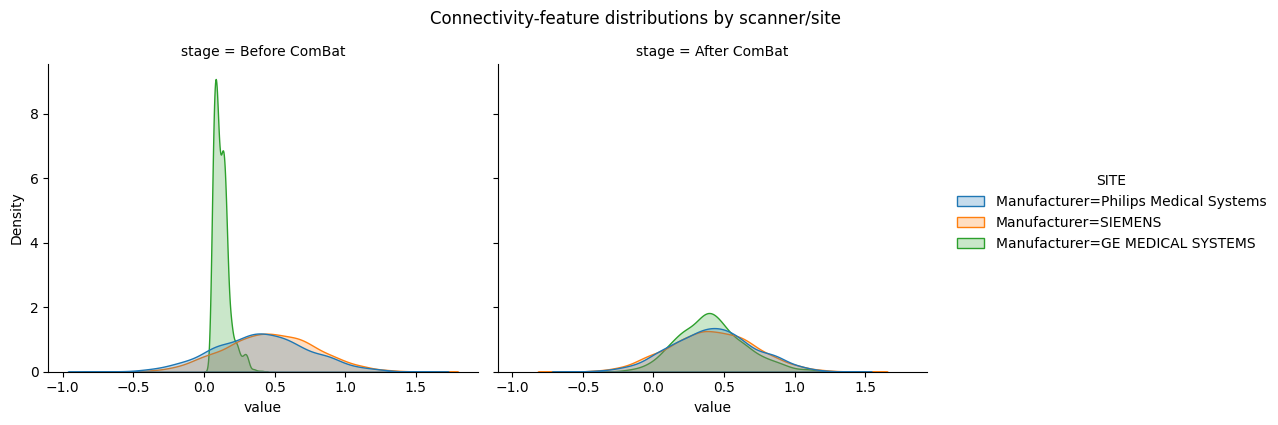

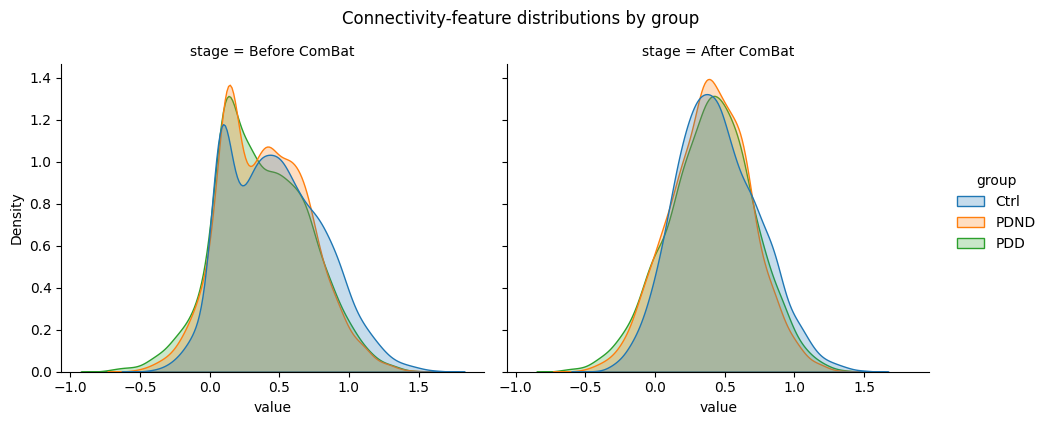

15-ROI count: 15
Harmonized: True

15-ROI global metrics, ComBat harmonized - Ctrl_vs_PDND


,metric,U,p_raw,p_fdr,significant_fdr
0,betweenness,438.0,0.323694,0.994643,False
1,strength,548.0,0.633601,0.994643,False
2,clustering,528.0,0.835135,0.994643,False
3,efficiency,511.0,0.994643,0.994643,False



15-ROI global metrics, ComBat harmonized - Ctrl_vs_PDD


,metric,U,p_raw,p_fdr,significant_fdr
0,clustering,400.0,0.808513,1.0,False
1,efficiency,427.0,0.869598,1.0,False
2,betweenness,422.0,0.931472,1.0,False
3,strength,416.0,1.000000,1.0,False



15-ROI global metrics, ComBat harmonized - PDND_vs_PDD


,metric,U,p_raw,p_fdr,significant_fdr
0,betweenness,475.0,0.360371,0.78438,False
1,clustering,390.0,0.690116,0.78438,False
2,strength,397.0,0.772389,0.78438,False
3,efficiency,434.0,0.784380,0.78438,False


In [ ]:
roi15_results = run_analysis_scope(
    scope_name="15-ROI literature subset, ComBat harmonized",
    result_suffix="_15_harmonized",
    selected_rois=None,
    prefixes=LITERATURE_PREFIXES,
    harmonize=True,
    plot_harmonization_diagnostics=True,
)

df_graph_15 = roi15_results["df_global"]
df_graph_15.to_csv(OUTPUT_DIR / "df_graph_global_15_roi_harmonized_all_participants.csv", index=False)

print("15-ROI count:", len(roi15_results["roi_labels"]))
print("Harmonized:", roi15_results["harmonized"])
display_global_stats(roi15_results["global_stats"], title_prefix="15-ROI global metrics, ComBat harmonized")

## 4.2 Review selected 15-ROI local results


Ctrl vs PDD_15_harmonized_nodal_strength
No ROIs with p < 0.05.

PDND vs PDD_15_harmonized_nodal_strength
No ROIs with p < 0.05.

Ctrl vs PDD_15_harmonized_nodal_betweenness
No ROIs with p < 0.05.

PDND vs PDD_15_harmonized_nodal_betweenness
No ROIs with p < 0.05.

Ctrl vs PDD_15_harmonized_nodal_clustering
ROIs with p < 0.05: 1


,ROI_name,metric,comparison,network,delta_mean_group2_minus_group1,p_uncorrected,p_fdr,significant_uncorrected,significant_fdr
0,"networks.FrontoParietal.PPC (L) (-46,-58,49)",nodal_clustering,Ctrl_vs_PDD,FrontoParietal,0.019115,0.040591,0.522919,True,False


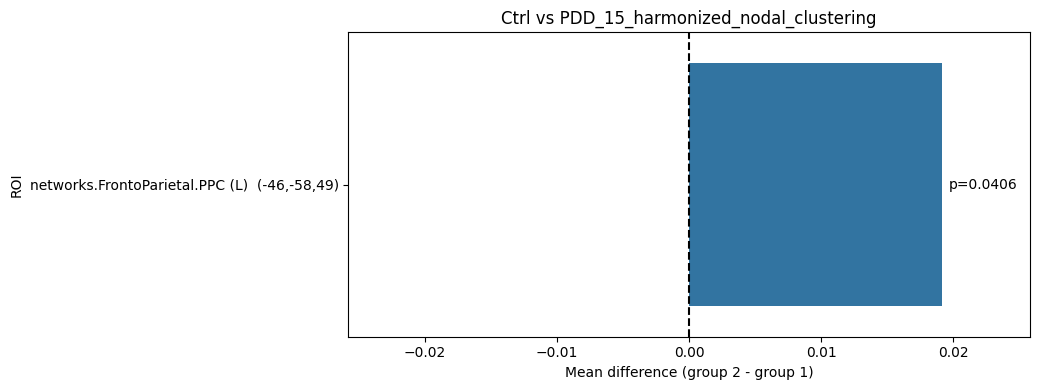


PDND vs PDD_15_harmonized_nodal_clustering
No ROIs with p < 0.05.

Ctrl vs PDD_15_harmonized_nodal_participation
ROIs with p < 0.05: 1


,ROI_name,metric,comparison,network,delta_mean_group2_minus_group1,p_uncorrected,p_fdr,significant_uncorrected,significant_fdr
0,"networks.DefaultMode.LP (R) (47,-67,29)",nodal_participation,Ctrl_vs_PDD,DefaultMode,-0.021308,0.032826,0.492393,True,False


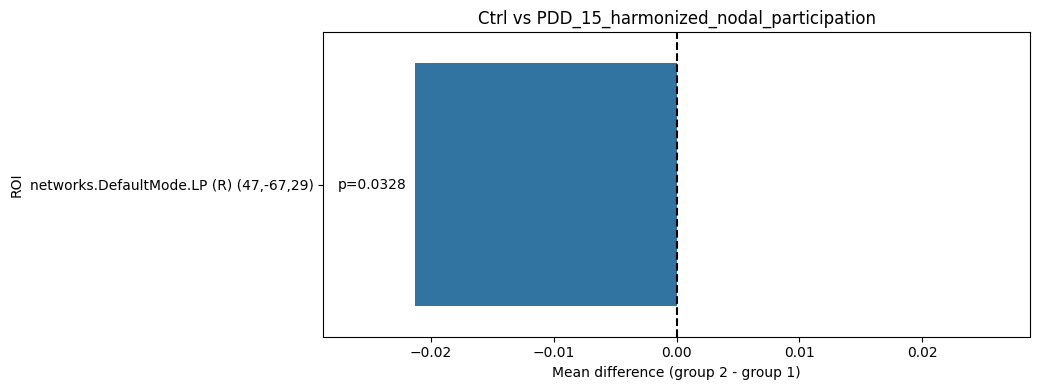


PDND vs PDD_15_harmonized_nodal_participation
No ROIs with p < 0.05.

Ctrl vs PDD_15_harmonized_within_module_strength_zscore
ROIs with p < 0.05: 1


,ROI_name,metric,comparison,network,delta_mean_group2_minus_group1,p_uncorrected,p_fdr,significant_uncorrected,significant_fdr
0,"networks.DefaultMode.MPFC (1,55,-3)",within_module_strength_zscore,Ctrl_vs_PDD,DefaultMode,-0.011111,0.048238,0.72357,True,False


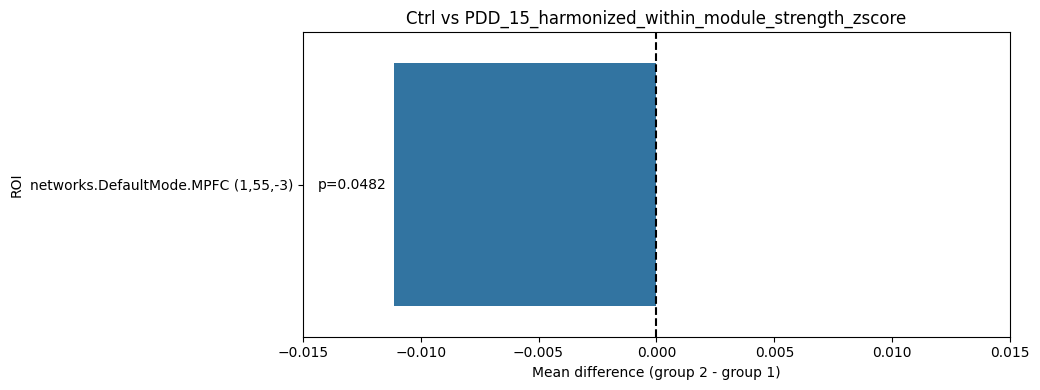


PDND vs PDD_15_harmonized_within_module_strength_zscore
No ROIs with p < 0.05.


In [ ]:
# Review the PDD-related comparisons for every local metric.
# Ctrl_vs_PDND is still computed and saved, but is not plotted here to keep the output focused.
roi15_keys_to_review = [
    f"{COMPARISON_TAGS[(g1, g2)]}_15_harmonized_{metric_name}"
    for metric_name in LOCAL_METRICS
    for g1, g2 in [("Ctrl", "PDD"), ("PDND", "PDD")]
]

review_selected_comparisons(
    roi15_results["local_results"],
    roi15_keys_to_review,
    reference_roi_labels=roi15_results["roi_labels"],
    p_threshold=P_THRESHOLD,
    n=TOP_N,
)


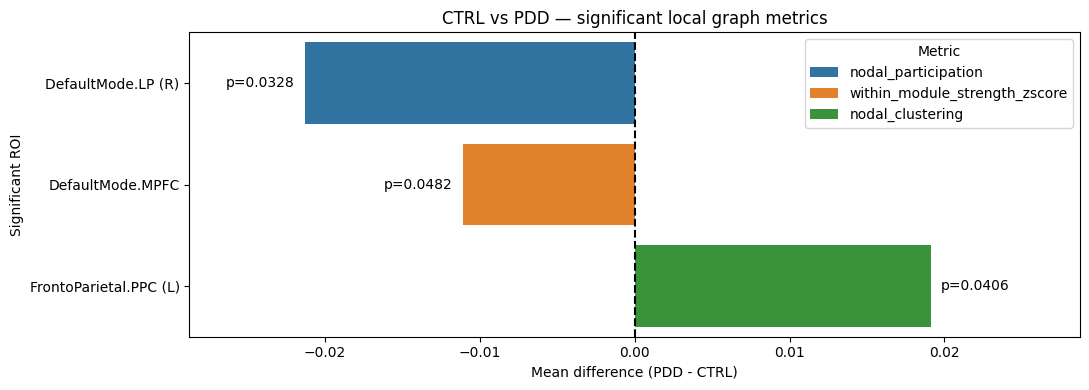

In [ ]:
significant = plot_combined_metric_rois(
    selected_rows_by_metric={
        "nodal_clustering": roi15_results["local_results"]['Ctrl vs PDD_15_harmonized_nodal_clustering'],
        "nodal_participation": roi15_results["local_results"]['Ctrl vs PDD_15_harmonized_nodal_participation'],
        "within_module_strength_zscore": roi15_results["local_results"]['Ctrl vs PDD_15_harmonized_within_module_strength_zscore'],
    },
    title="CTRL vs PDD — significant local graph metrics",
    group1_name="CTRL",
    group2_name="PDD",
)

In [ ]:
significant = significant.drop(columns=[
    'group_1',
    'group_2',
    'mean_group_1',
    'mean_group_2',
    'median_group_1',
    'median_group_2',
    'abs_delta',
    'ROI_clean_label',
    'u_stat',
    'network',
    ])
significant

,metric,ROI_name,comparison,delta_mean_group2_minus_group1,p_uncorrected,p_fdr,significant_fdr,significant_uncorrected
0,nodal_participation,"networks.DefaultMode.LP (R) (47,-67,29)",Ctrl_vs_PDD,-0.021308,0.032826,0.492393,False,True
1,within_module_strength_zscore,"networks.DefaultMode.MPFC (1,55,-3)",Ctrl_vs_PDD,-0.011111,0.048238,0.723570,False,True
2,nodal_clustering,"networks.FrontoParietal.PPC (L) (-46,-58,49)",Ctrl_vs_PDD,0.019115,0.040591,0.522919,False,True



Ctrl vs PDD_15_harmonized_nodal_strength: no significant ROIs to plot.
No significant ROIs to plot for: Ctrl vs PDD_15_harmonized_nodal_strength


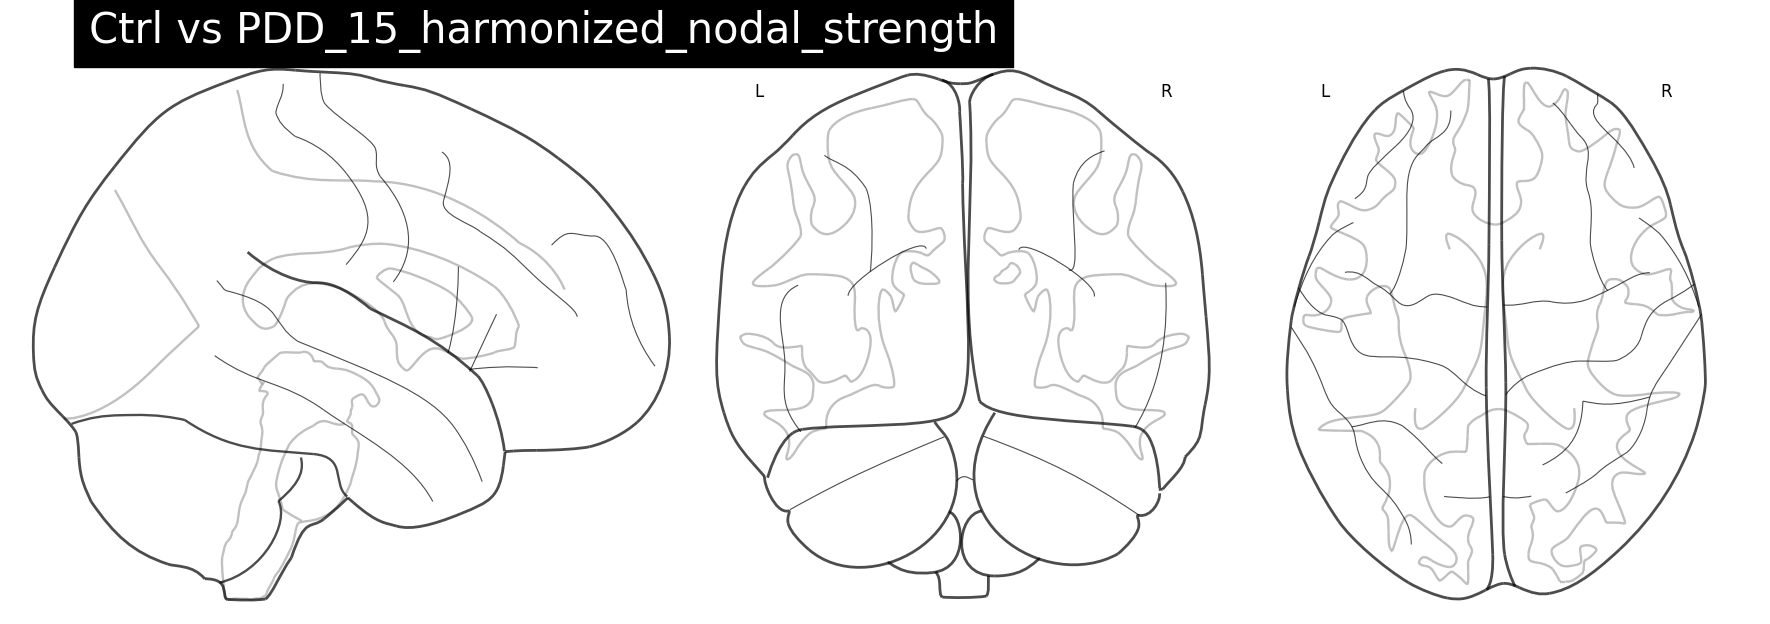


PDND vs PDD_15_harmonized_nodal_strength: no significant ROIs to plot.
No significant ROIs to plot for: PDND vs PDD_15_harmonized_nodal_strength


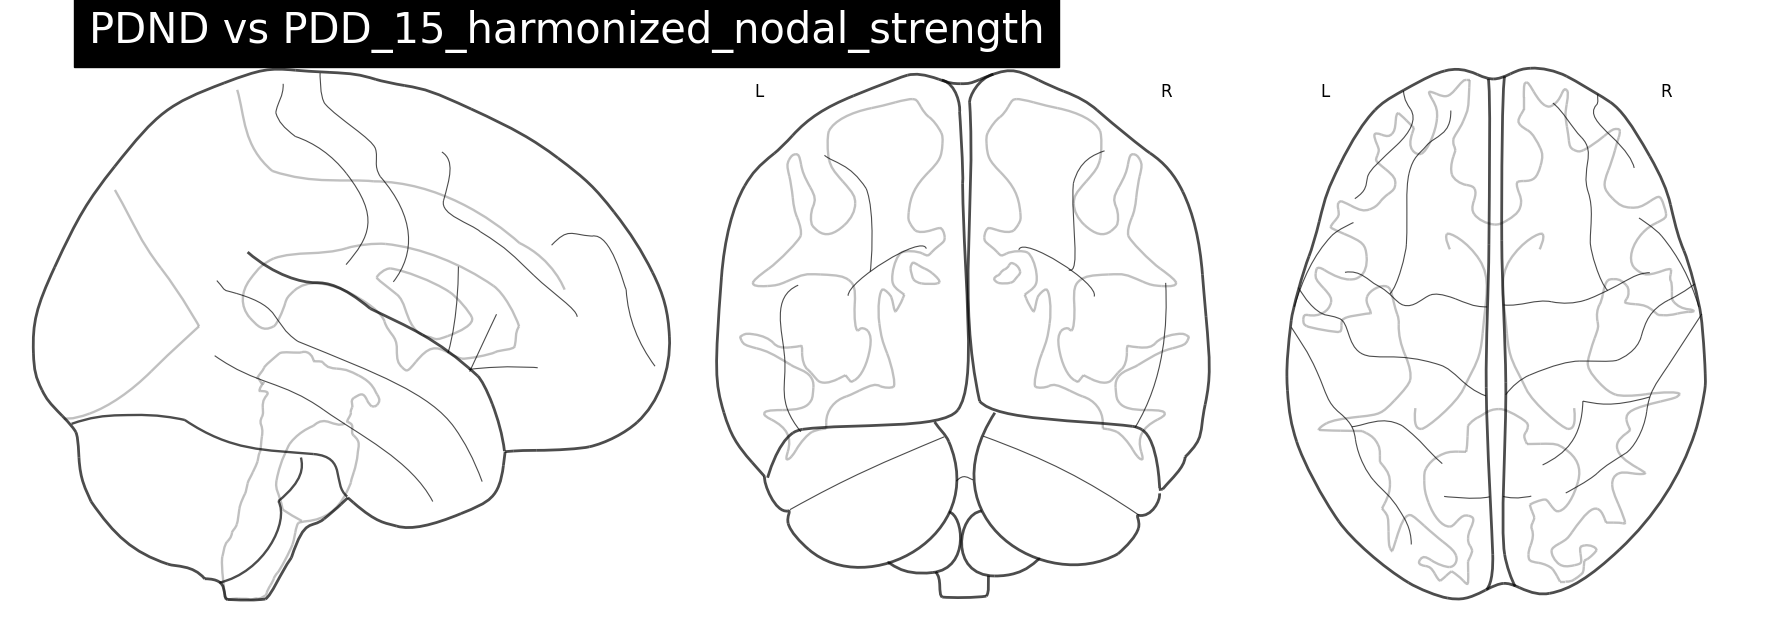


Ctrl vs PDD_15_harmonized_nodal_betweenness: no significant ROIs to plot.
No significant ROIs to plot for: Ctrl vs PDD_15_harmonized_nodal_betweenness


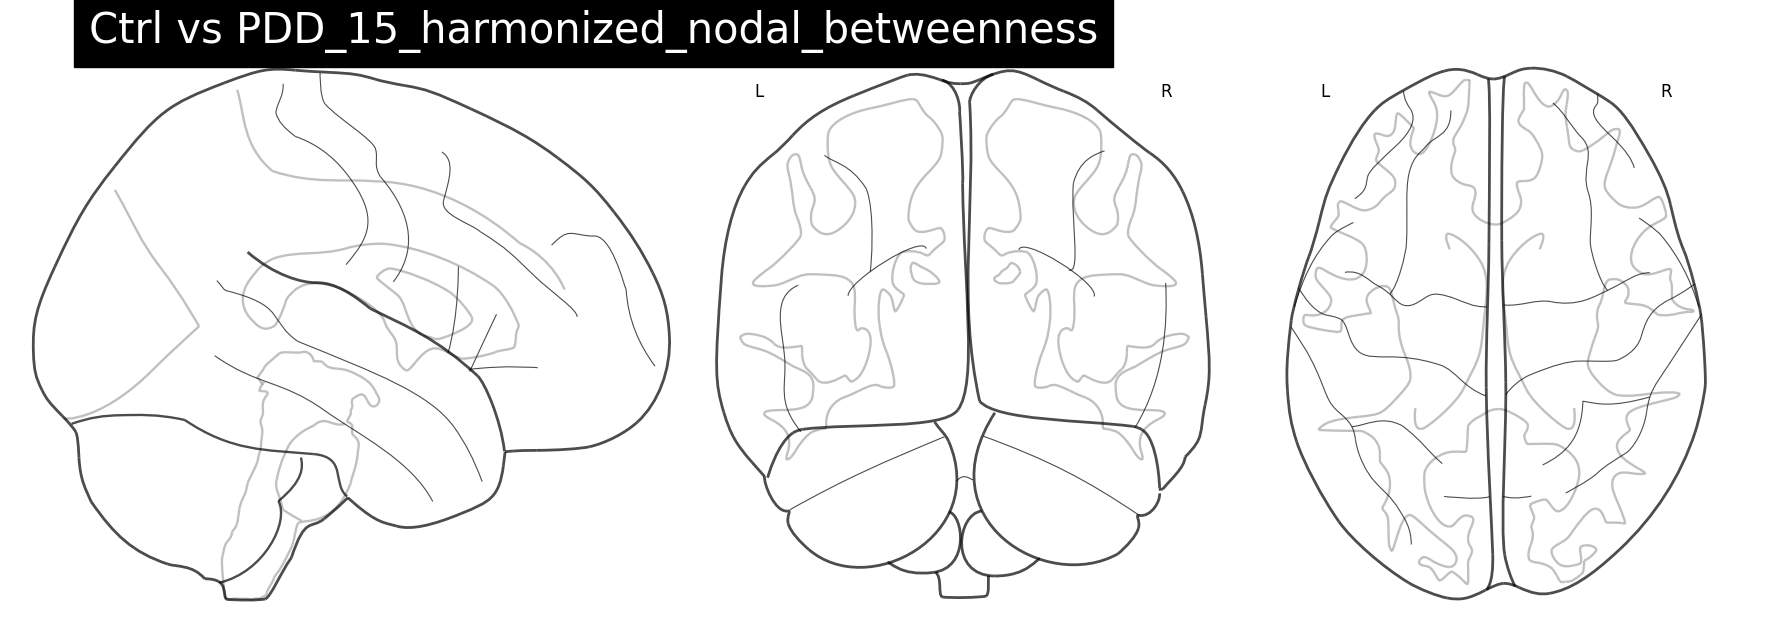


PDND vs PDD_15_harmonized_nodal_betweenness: no significant ROIs to plot.
No significant ROIs to plot for: PDND vs PDD_15_harmonized_nodal_betweenness


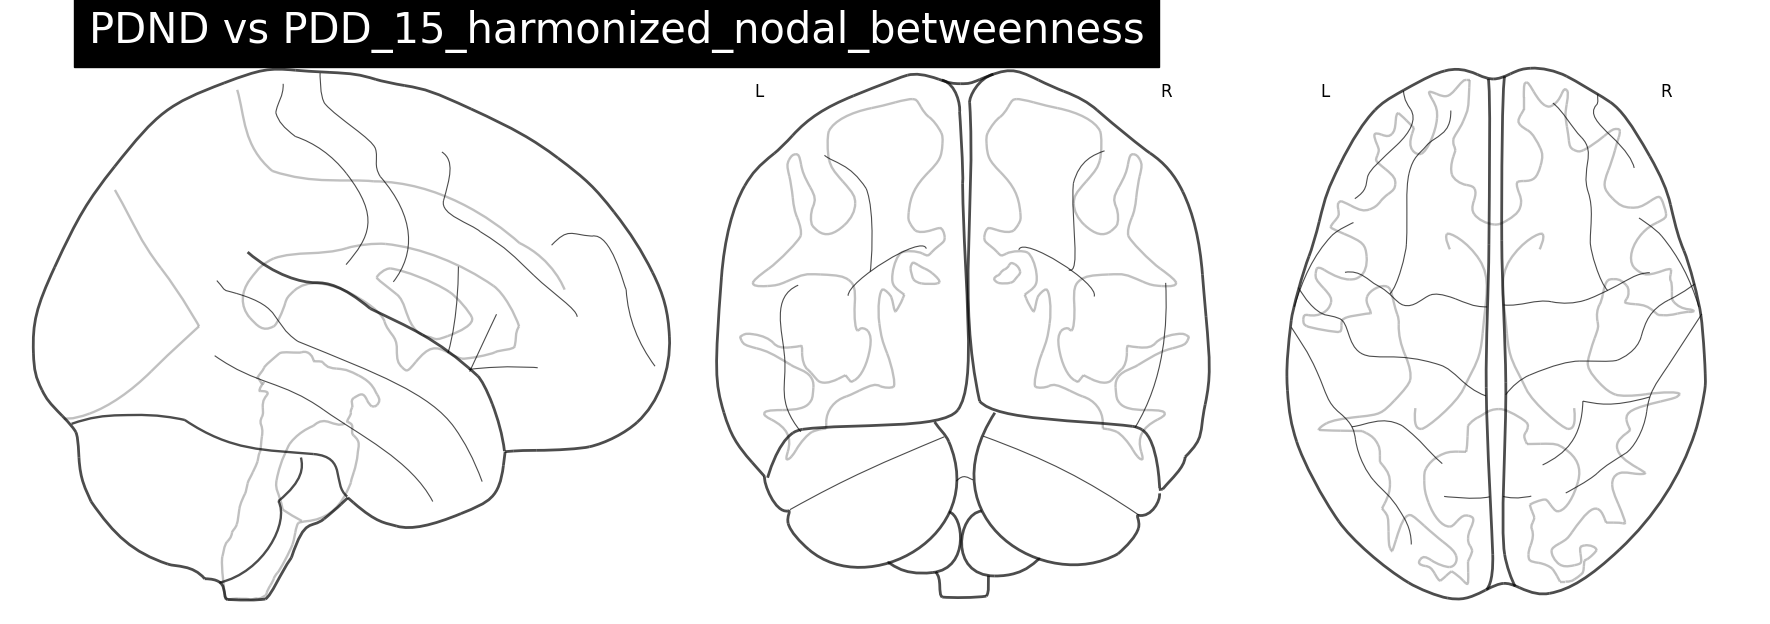

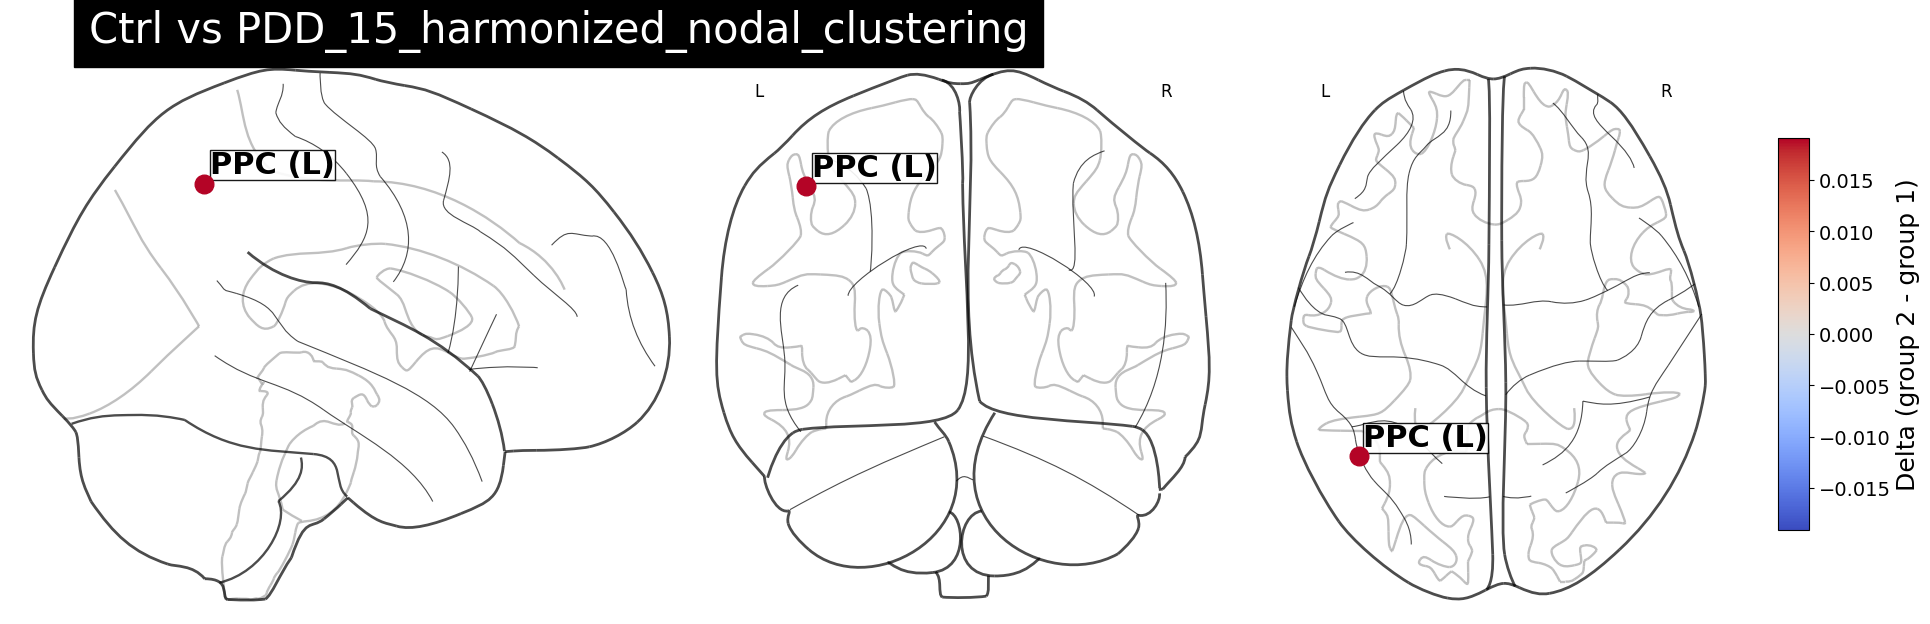

Plotted ROIs for Ctrl vs PDD_15_harmonized_nodal_clustering: 1
Connected ROIs are shown in light blue.

PDND vs PDD_15_harmonized_nodal_clustering: no significant ROIs to plot.
No significant ROIs to plot for: PDND vs PDD_15_harmonized_nodal_clustering


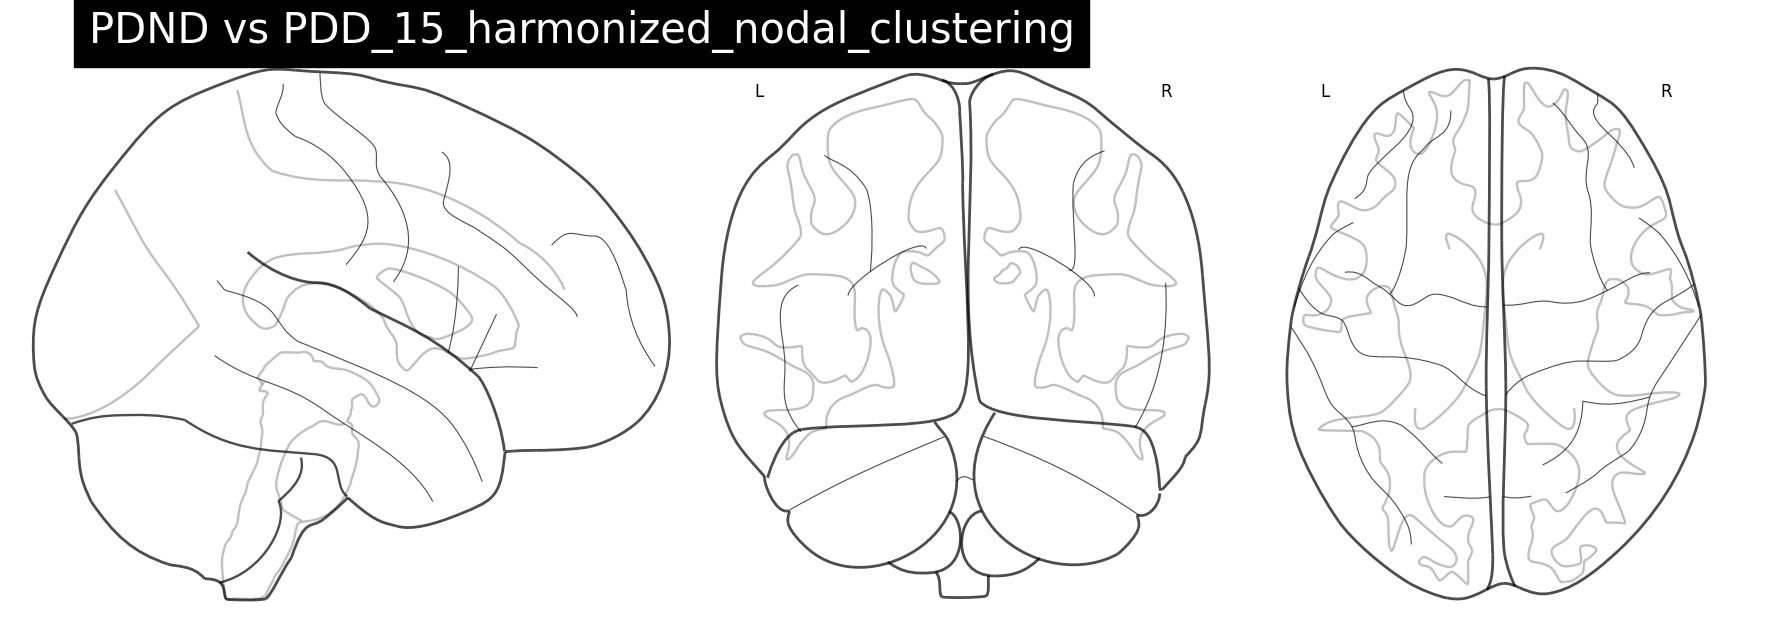

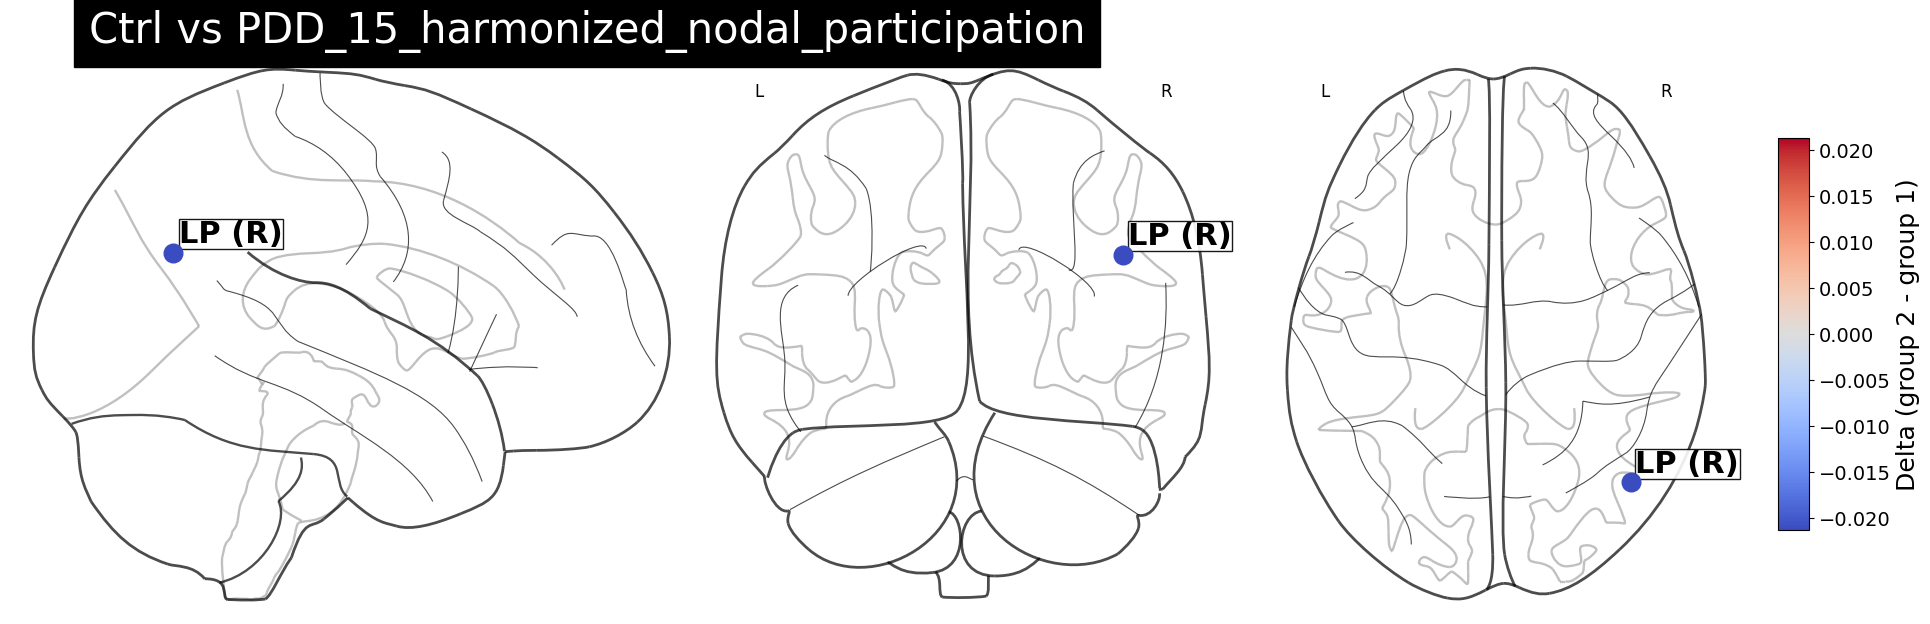

Plotted ROIs for Ctrl vs PDD_15_harmonized_nodal_participation: 1
Connected ROIs are shown in light blue.

PDND vs PDD_15_harmonized_nodal_participation: no significant ROIs to plot.
No significant ROIs to plot for: PDND vs PDD_15_harmonized_nodal_participation


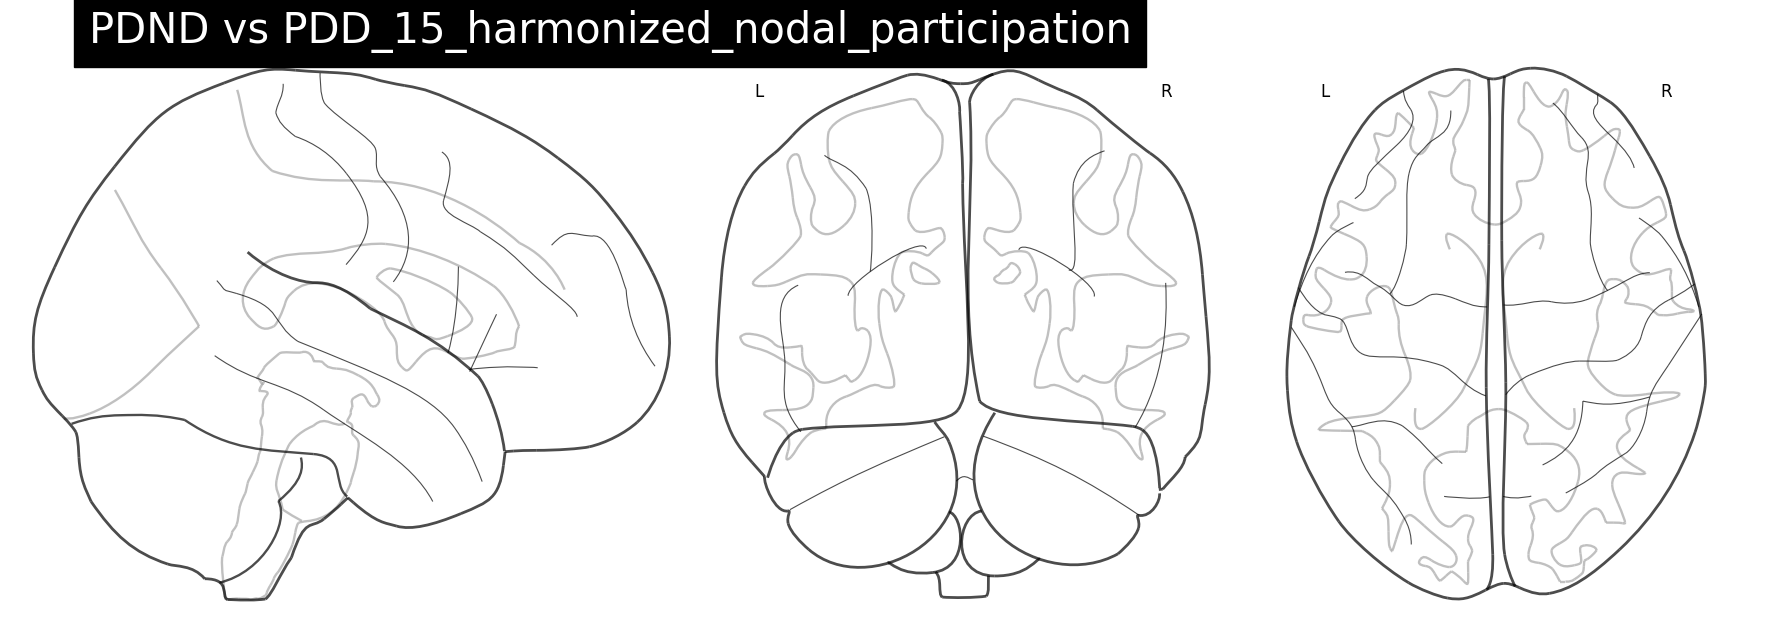

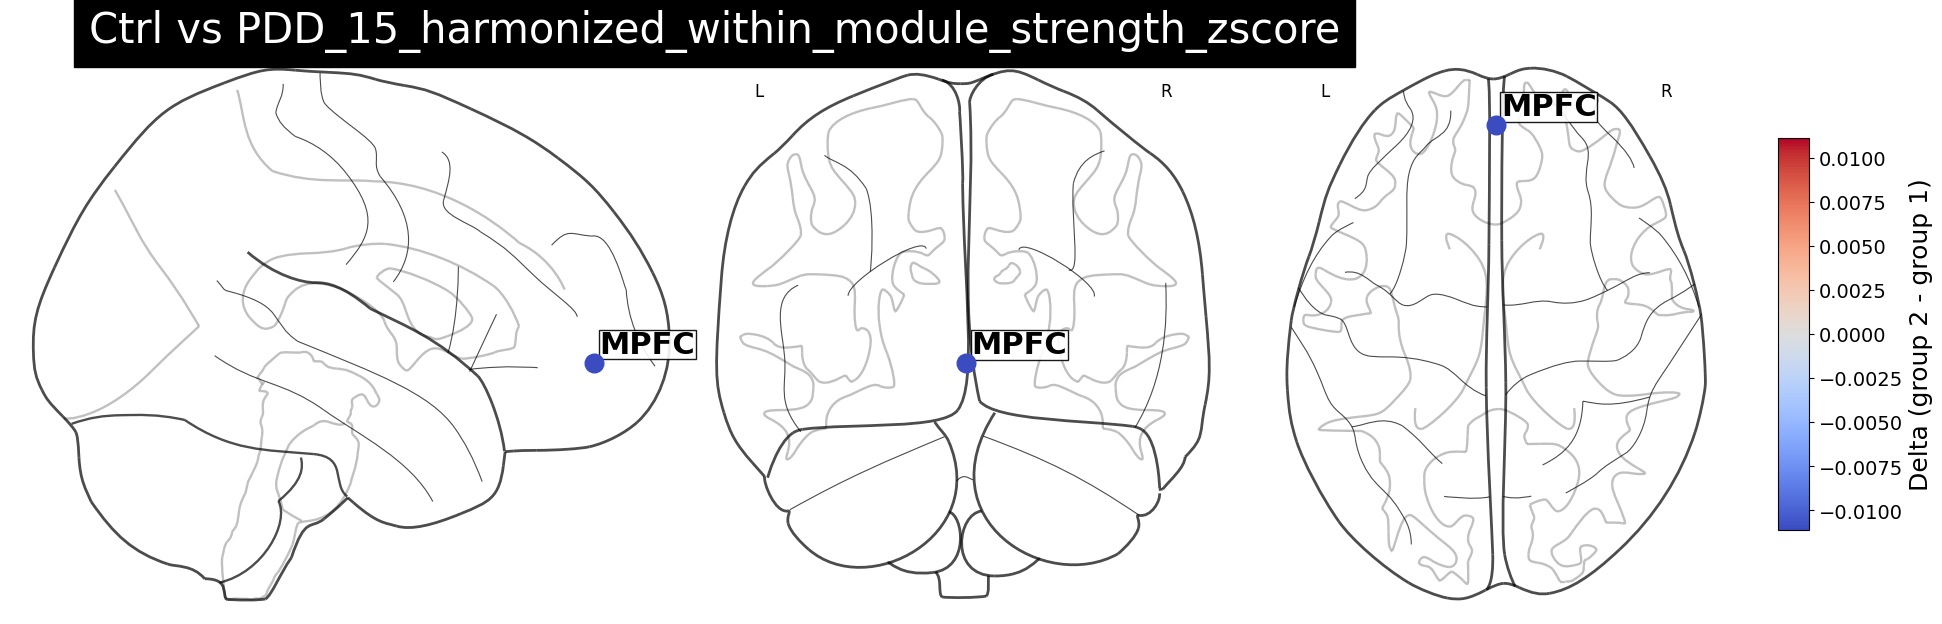

Plotted ROIs for Ctrl vs PDD_15_harmonized_within_module_strength_zscore: 1
Connected ROIs are shown in light blue.

PDND vs PDD_15_harmonized_within_module_strength_zscore: no significant ROIs to plot.
No significant ROIs to plot for: PDND vs PDD_15_harmonized_within_module_strength_zscore


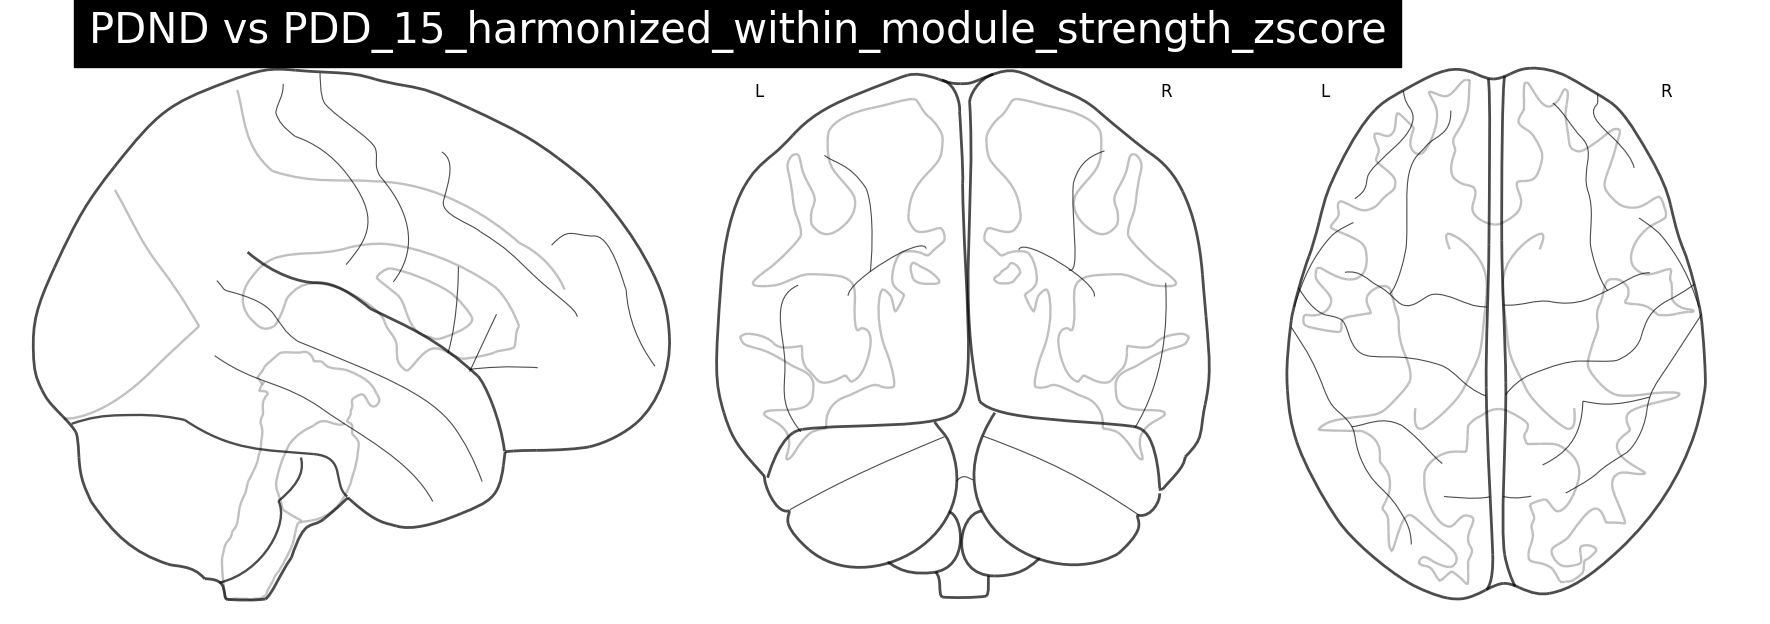

In [ ]:
for key in roi15_keys_to_review:
    if key not in roi15_results["local_results"]:
        print(f"\n{key}: result not found.")
        continue

    df_current = roi15_results["local_results"][key].copy()
    df_current = df_current[df_current["significant_uncorrected"] == True].copy()

    comparison_name = None
    if not df_current.empty:
        comparison_name = df_current["comparison"].iloc[0]
    else:
        print(f"\n{key}: no significant ROIs to plot.")

    plot_real_coordinate_brain(
        df=df_current,
        title=key,
        comparison=comparison_name,
        p_threshold=P_THRESHOLD,
        scope_results=roi15_results,
        top_k_neighbors=5,
        other_rois=False,
        node_size=180,
    )
